# Kapitel 4 — Ergebnisse FF1: Systematische Dynamikmuster

**Forschungsfrage:** Zeigen Finanzkennzahlen systematische Unterschiede in ihrer Veränderungsdynamik?

**Datenbasis:** 932 Unternehmen × 100 Quartale (Q1/2000 – Q4/2024) × 7 Kennzahlen, AR(1) auf erste Differenzen, individuell pro Unternehmen × Kennzahl-Paar geschätzt — insgesamt 6.521 Schätzungen.

Pro Sub-Section: Markdown-Erläuterung + Tabelle als pandas DataFrame + Plot direkt im Notebook.


In [56]:
# Setup
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

import analysis_helpers as ah
from analysis_helpers import RATIO_ORDER, RATIO_LABEL, RATIO_LAYER, SECTOR_ORDER

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
})

LAYER_COLORS = {"Profitabilität":"#2C5F8D","Liquidität":"#7FB069","Kapitalstruktur":"#C75D4F"}
QUAD_COLORS = {"KORREKTIV-STABIL":"#1F77B4","KORREKTIV-VOLATIL":"#D62728",
               "PERSISTENT-STABIL":"#2CA02C","PERSISTENT-VOLATIL":"#FF7F0E"}

print("Setup OK")


Setup OK


---
## 4.1 Analyse nach Kennzahl


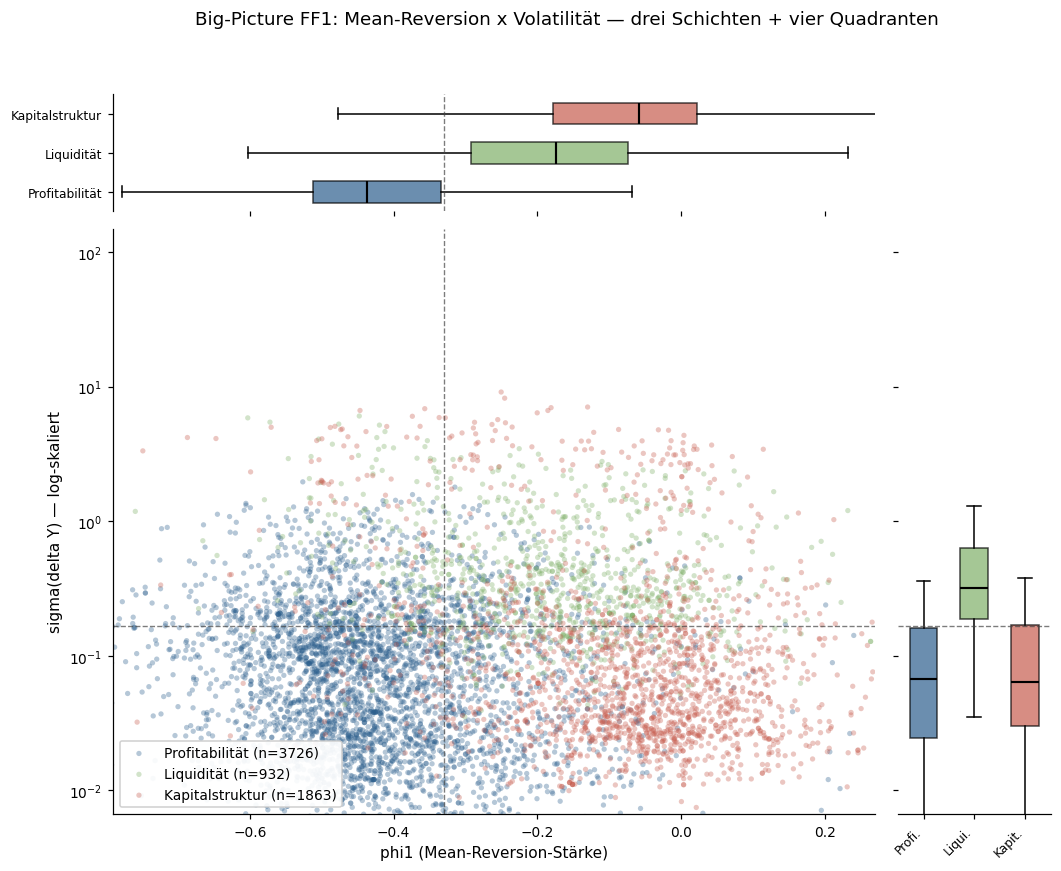

In [57]:
# Big-Picture: Joint Plot phi1 x sigma (log) mit Marginal-Boxplots pro Schicht
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter

ar_bp = ah.load_ar_features().dropna(subset=['phi1', 'sigma_diff'])
ar_bp = ar_bp[ar_bp['sigma_diff'] > 0]
ar_bp['layer'] = ar_bp['ratio'].map(RATIO_LAYER)

LAYER_ORDER_BP = ['Profitabilität', 'Liquidität', 'Kapitalstruktur']
phi1_med_bp = ar_bp['phi1'].median()
sigma_med_bp = ar_bp['sigma_diff'].median()
phi_lo, phi_hi = ar_bp['phi1'].quantile([0.005, 0.995])
sig_lo = ar_bp['sigma_diff'].quantile(0.01)
sig_hi = ar_bp['sigma_diff'].quantile(0.99)

fig = plt.figure(figsize=(11, 8.5))
gs = GridSpec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5],
              hspace=0.05, wspace=0.05)
ax_main  = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

for layer in LAYER_ORDER_BP:
    sub = ar_bp[ar_bp['layer'] == layer]
    ax_main.scatter(sub['phi1'], sub['sigma_diff'],
                     c=LAYER_COLORS[layer], alpha=0.35, s=12,
                     edgecolors='none', label=f'{layer} (n={len(sub)})')

ax_main.axvline(phi1_med_bp,  color='#444', linewidth=0.9, linestyle='--', alpha=0.7)
ax_main.axhline(sigma_med_bp, color='#444', linewidth=0.9, linestyle='--', alpha=0.7)

ax_main.set_xlabel('phi1 (Mean-Reversion-Stärke)')
ax_main.set_ylabel('sigma(delta Y) — log-skaliert')
ax_main.set_xlim(phi_lo, phi_hi)
ax_main.set_yscale('log')
ax_main.set_ylim(sig_lo, sig_hi)
# Dezimal-Beschriftung, keine Minor-Ticks
ax_main.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:g}'))
ax_main.minorticks_off()
ax_main.legend(loc='lower left', framealpha=0.92)

# Marginal-Boxplot oben (phi1)
top_data = [ar_bp[ar_bp['layer'] == l]['phi1'].values for l in LAYER_ORDER_BP]
top_colors = [LAYER_COLORS[l] for l in LAYER_ORDER_BP]
bp_top = ax_top.boxplot(top_data, vert=False, widths=0.55, patch_artist=True,
                         positions=range(len(LAYER_ORDER_BP)), showfliers=False,
                         medianprops=dict(color='black', linewidth=1.4))
for patch, c in zip(bp_top['boxes'], top_colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax_top.set_yticks(range(len(LAYER_ORDER_BP)))
ax_top.set_yticklabels(LAYER_ORDER_BP, fontsize=8)
ax_top.tick_params(axis='x', labelbottom=False)
ax_top.spines['bottom'].set_visible(False)
ax_top.set_xlim(phi_lo, phi_hi)
ax_top.axvline(phi1_med_bp, color='#444', linewidth=0.9, linestyle='--', alpha=0.7)

# Marginal-Boxplot rechts (sigma) — auch log
right_data = [ar_bp[ar_bp['layer'] == l]['sigma_diff'].values for l in LAYER_ORDER_BP]
bp_right = ax_right.boxplot(right_data, vert=True, widths=0.55, patch_artist=True,
                              positions=range(len(LAYER_ORDER_BP)), showfliers=False,
                              medianprops=dict(color='black', linewidth=1.4))
for patch, c in zip(bp_right['boxes'], top_colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax_right.set_xticks(range(len(LAYER_ORDER_BP)))
ax_right.set_xticklabels([l[:5] + '.' for l in LAYER_ORDER_BP],
                          fontsize=8, rotation=45, ha='right')
ax_right.tick_params(axis='y', labelleft=False)
ax_right.spines['left'].set_visible(False)
ax_right.set_yscale('log')
ax_right.set_ylim(sig_lo, sig_hi)
ax_right.minorticks_off()
ax_right.axhline(sigma_med_bp, color='#444', linewidth=0.9, linestyle='--', alpha=0.7)

fig.suptitle('Big-Picture FF1: Mean-Reversion x Volatilität — drei Schichten + vier Quadranten',
              fontsize=12, y=0.97)
plt.show()


Die Verdichtung pro Kennzahl ergibt eine Rangordnung der Mean-Reversion-Stärke mit drei Dynamiktypen: Profitabilität, Liquidität, Kapitalstruktur. Im Folgenden wird diese Schichtung im Detail analysiert.


### 4.1.1 Überblick der drei Dynamiktypen

Sieben Kennzahlen ordnen sich in eine Rangordnung der Korrekturstärke (φ₁): Profitabilität (≈ −0,43) → Liquidität (≈ −0,17) → Kapitalstruktur (≈ −0,04).

**Tab. 4.1** — Mittelwert, Median, Std von φ₁ und σ(ΔY), Signifikanzrate, Halblebensdauer (τ-Formel).


In [58]:
# Tab. 4.1 — Drei-Dynamiktypen-Übersicht
summary = ah.add_halflife_columns(ah.load_ar_summary())
ar = ah.load_ar_features()
sigma_std = ar.groupby("ratio")["sigma_diff"].std().round(4).to_dict()
summary["sigma_std"] = summary["ratio"].map(sigma_std)

order_pretty = ["fcf_margin","ROA","EBIT_margin","ROE",
                "current_ratio","debt_to_equity","equity_ratio"]
tab_4_1 = summary.set_index("ratio").reindex(order_pretty).reset_index()
tab_4_1[["ratio","n","phi1_mean","phi1_median","phi1_std",
         "sigma_mean","sigma_median","sigma_std",
         "phi1_signif_pct","hl_quarters_tau","hl_years_tau"]].round(3)


,ratio,n,phi1_mean,phi1_median,phi1_std,sigma_mean,sigma_median,sigma_std,phi1_signif_pct,hl_quarters_tau,hl_years_tau
0,fcf_margin,932,-0.459,-0.459,0.145,0.259,0.165,0.268,96.566,1.130,0.282
1,ROA,931,-0.414,-0.431,0.139,0.019,0.017,0.012,92.266,1.229,0.307
2,EBIT_margin,932,-0.401,-0.431,0.155,0.182,0.111,0.212,89.807,1.230,0.307
3,ROE,931,-0.404,-0.427,0.151,0.079,0.048,0.077,90.011,1.243,0.311
4,current_ratio,932,-0.186,-0.174,0.159,0.600,0.318,0.765,45.601,3.633,0.908
5,debt_to_equity,931,-0.112,-0.089,0.192,0.744,0.166,1.329,32.438,7.401,1.850
6,equity_ratio,932,-0.053,-0.040,0.157,0.039,0.031,0.027,18.562,17.067,4.267


**Hinweis Halblebensdauer:** Die Formel t½ = ln(0,5) / ln(1+φ₁) ist nur für φ₁ < 0 wohldefiniert. Hier auf die Mediane angewendet, die alle negativ sind. Einzelfirmen mit positivem φ₁ werden in 4.1.4 separat diskutiert.

**Klassische Hierarchie-Visualisierung — Boxplots φ₁ und σ(ΔY) nebeneinander:**


/var/folders/99/50l4jq3j3f10cj2hwpl44xd80000gn/T/ipykernel_97541/2239102260.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_phi, labels=[RATIO_LABEL[r] for r in RATIO_ORDER],
/var/folders/99/50l4jq3j3f10cj2hwpl44xd80000gn/T/ipykernel_97541/2239102260.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(data_sig, labels=[RATIO_LABEL[r] for r in RATIO_ORDER],


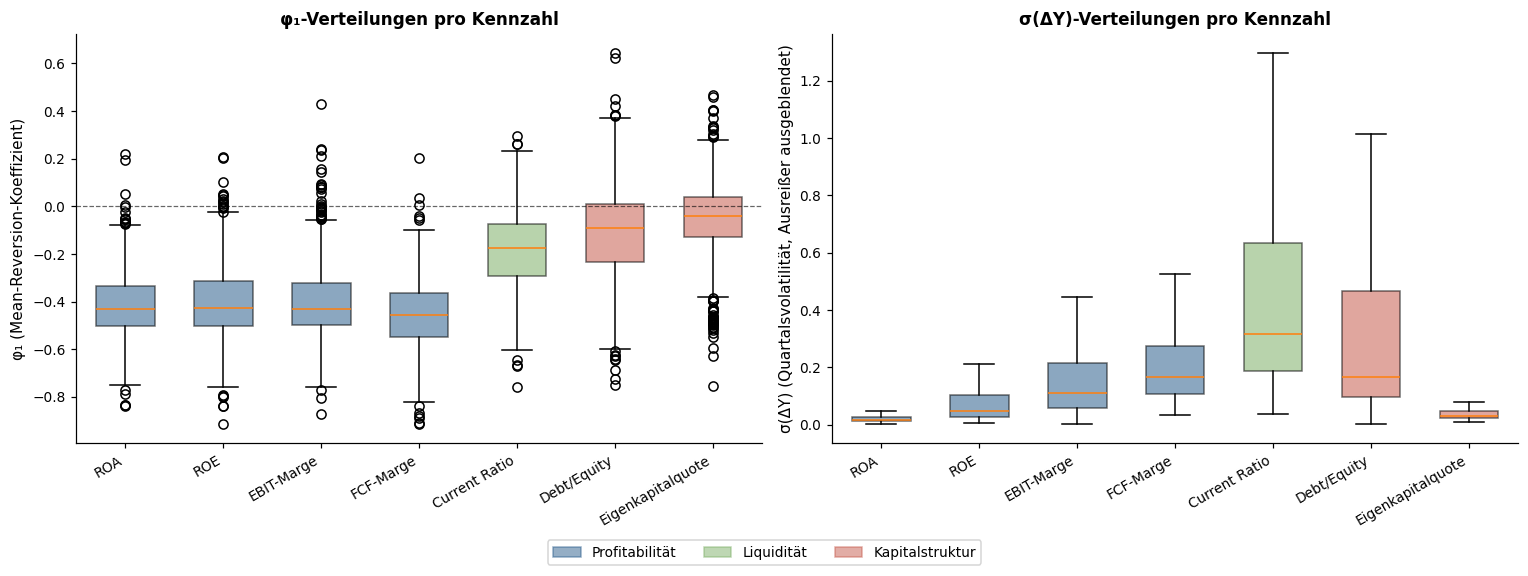

In [59]:
# Boxplot der φ₁- und σ-Verteilungen — klassische Drei-Dynamiktypen-Darstellung
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# φ₁
data_phi = [ar[ar["ratio"]==r]["phi1"].dropna() for r in RATIO_ORDER]
colors_phi = [LAYER_COLORS[RATIO_LAYER[r]] for r in RATIO_ORDER]
bp = ax1.boxplot(data_phi, labels=[RATIO_LABEL[r] for r in RATIO_ORDER],
                  patch_artist=True, widths=0.6, showmeans=False)
for patch, c in zip(bp["boxes"], colors_phi):
    patch.set_facecolor(c); patch.set_alpha(0.55)
ax1.axhline(0, color="black", ls="--", lw=0.8, alpha=0.6)
ax1.set_ylabel("φ₁ (Mean-Reversion-Koeffizient)")
ax1.set_title("φ₁-Verteilungen pro Kennzahl", fontweight="bold")
plt.setp(ax1.get_xticklabels(), rotation=30, ha="right")

# σ
data_sig = [ar[ar["ratio"]==r]["sigma_diff"].dropna() for r in RATIO_ORDER]
bp2 = ax2.boxplot(data_sig, labels=[RATIO_LABEL[r] for r in RATIO_ORDER],
                   patch_artist=True, widths=0.6, showfliers=False)
for patch, c in zip(bp2["boxes"], colors_phi):
    patch.set_facecolor(c); patch.set_alpha(0.55)
ax2.set_ylabel("σ(ΔY) (Quartalsvolatilität, Ausreißer ausgeblendet)")
ax2.set_title("σ(ΔY)-Verteilungen pro Kennzahl", fontweight="bold")
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")

legend = [mpatches.Patch(color=c, alpha=0.5, label=l) for l,c in LAYER_COLORS.items()]
fig.legend(handles=legend, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()


**KDE-Verteilungen** — feinere Sicht auf die Verteilungsform pro Kennzahl:

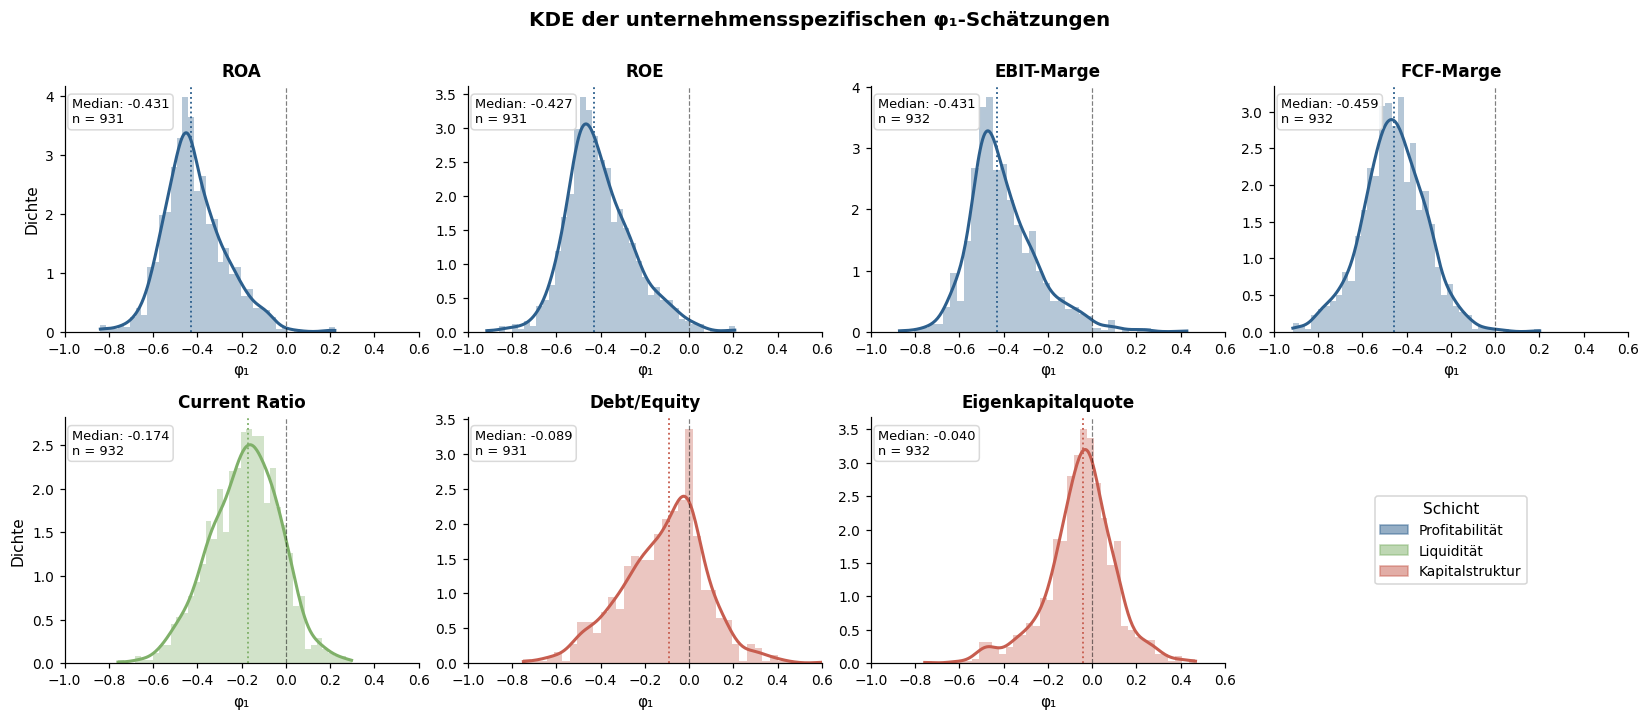

In [60]:
# Abb. 4.1 — KDE φ₁
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
axes = axes.flatten()

for i, ratio in enumerate(RATIO_ORDER):
    ax = axes[i]
    sub = ar[ar["ratio"]==ratio]["phi1"].dropna()
    color = LAYER_COLORS[RATIO_LAYER[ratio]]
    ax.hist(sub, bins=40, density=True, color=color, alpha=0.35, edgecolor="none")
    kde = stats.gaussian_kde(sub)
    xx = np.linspace(sub.min(), sub.max(), 250)
    ax.plot(xx, kde(xx), color=color, lw=2)
    ax.axvline(0, color="black", ls="--", lw=0.8, alpha=0.5)
    ax.axvline(sub.median(), color=color, ls=":", lw=1.2)
    ax.text(0.02, 0.95, f"Median: {sub.median():.3f}\nn = {len(sub)}",
            transform=ax.transAxes, fontsize=8.5, va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="lightgray", alpha=0.85))
    ax.set_title(RATIO_LABEL[ratio], fontweight="bold")
    ax.set_xlabel("φ₁")
    if i % 4 == 0: ax.set_ylabel("Dichte")
    ax.set_xlim(-1.0, 0.6)

axes[7].axis("off")
axes[7].legend(handles=legend, loc="center", title="Schicht")
fig.suptitle("KDE der unternehmensspezifischen φ₁-Schätzungen",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()


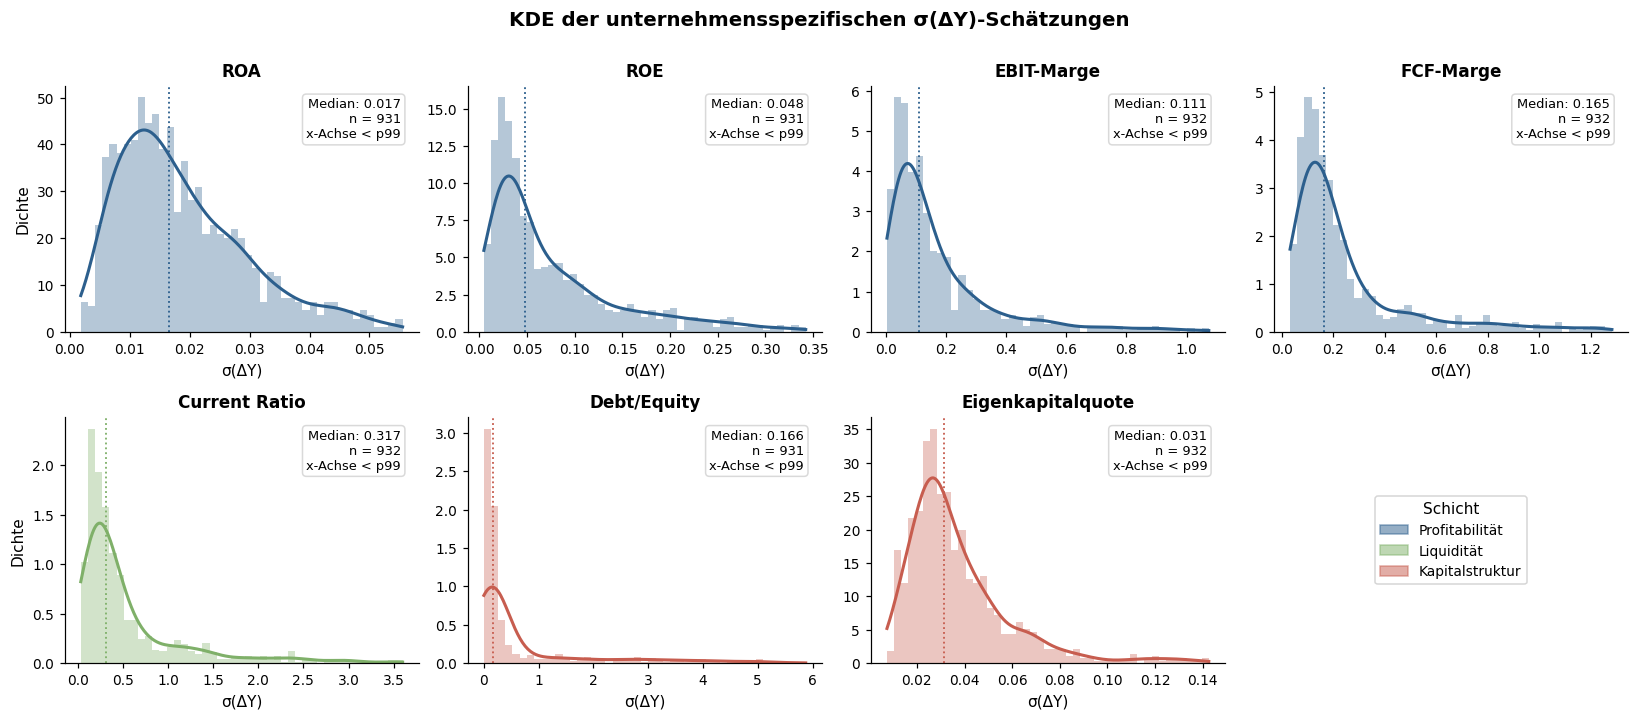

In [61]:
# Abb. 4.2 — KDE σ(ΔY) (gecappt auf 99-Perzentil)
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
axes = axes.flatten()

for i, ratio in enumerate(RATIO_ORDER):
    ax = axes[i]
    sub = ar[ar["ratio"]==ratio]["sigma_diff"].dropna()
    p99 = sub.quantile(0.99)
    sub_cap = sub[sub <= p99]
    color = LAYER_COLORS[RATIO_LAYER[ratio]]
    ax.hist(sub_cap, bins=45, density=True, color=color, alpha=0.35, edgecolor="none")
    kde = stats.gaussian_kde(sub_cap)
    xx = np.linspace(sub_cap.min(), sub_cap.max(), 250)
    ax.plot(xx, kde(xx), color=color, lw=2)
    ax.axvline(sub.median(), color=color, ls=":", lw=1.2)
    ax.text(0.95, 0.95, f"Median: {sub.median():.3f}\nn = {len(sub)}\nx-Achse < p99",
            transform=ax.transAxes, fontsize=8.5, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="lightgray", alpha=0.85))
    ax.set_title(RATIO_LABEL[ratio], fontweight="bold")
    ax.set_xlabel("σ(ΔY)")
    if i % 4 == 0: ax.set_ylabel("Dichte")

axes[7].axis("off")
axes[7].legend(handles=legend, loc="center", title="Schicht")
fig.suptitle("KDE der unternehmensspezifischen σ(ΔY)-Schätzungen",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()


**Modellgüte pro Kennzahl** — Signifikanzrate und Median-R² als Bar-Chart:

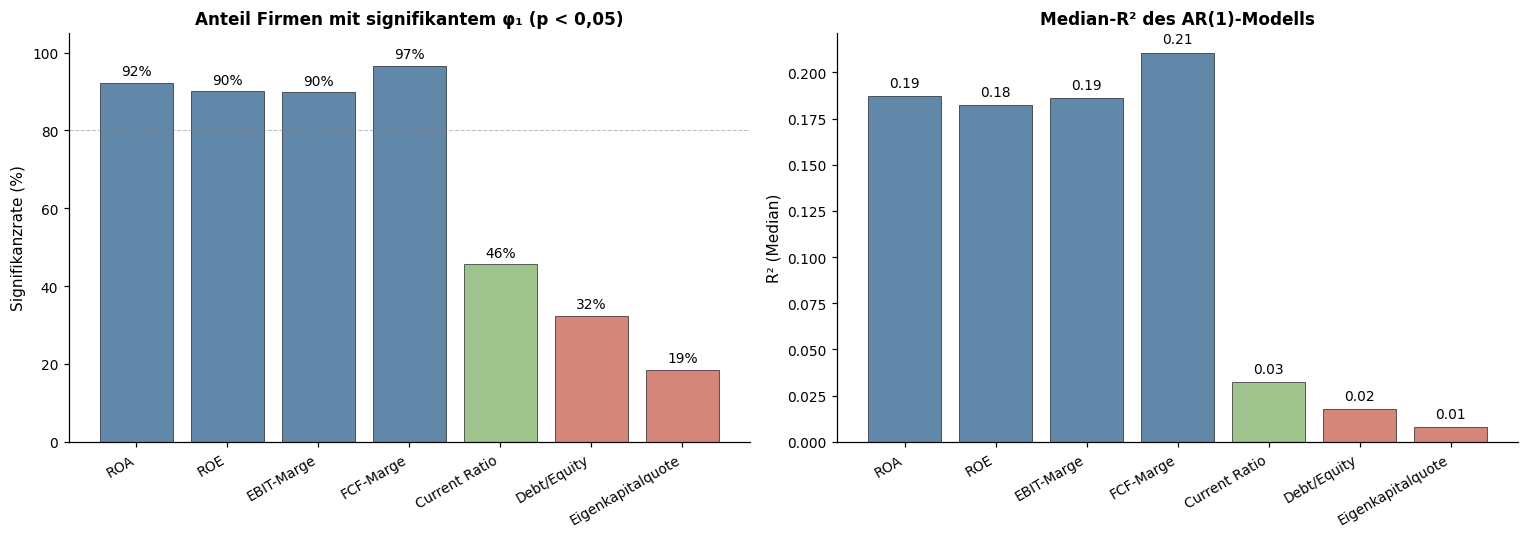

In [62]:
# Modellgüte: Signifikanzrate + R²-Median pro Kennzahl
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Signifikanzrate
sig_rate = [(ar[ar["ratio"]==r]["phi1_pval"] < 0.05).mean()*100 for r in RATIO_ORDER]
ax1.bar(range(len(RATIO_ORDER)), sig_rate, color=colors_phi, alpha=0.75, edgecolor="black", lw=0.5)
ax1.set_xticks(range(len(RATIO_ORDER)))
ax1.set_xticklabels([RATIO_LABEL[r] for r in RATIO_ORDER], rotation=30, ha="right")
ax1.set_ylabel("Signifikanzrate (%)")
ax1.set_title("Anteil Firmen mit signifikantem φ₁ (p < 0,05)", fontweight="bold")
ax1.axhline(80, color="gray", ls="--", lw=0.7, alpha=0.5)
ax1.set_ylim(0, 105)
for i, v in enumerate(sig_rate):
    ax1.text(i, v+2, f"{v:.0f}%", ha="center", fontsize=9)

# R²
r2_med = [ar[ar["ratio"]==r]["r_squared"].median() for r in RATIO_ORDER]
ax2.bar(range(len(RATIO_ORDER)), r2_med, color=colors_phi, alpha=0.75, edgecolor="black", lw=0.5)
ax2.set_xticks(range(len(RATIO_ORDER)))
ax2.set_xticklabels([RATIO_LABEL[r] for r in RATIO_ORDER], rotation=30, ha="right")
ax2.set_ylabel("R² (Median)")
ax2.set_title("Median-R² des AR(1)-Modells", fontweight="bold")
for i, v in enumerate(r2_med):
    ax2.text(i, v+0.005, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


### 4.1.2 Profitabilitätsgruppe

Vier Kennzahlen mit konsistent starker Mean-Reversion (φ₁ ≈ −0,43 bis −0,46). Differenzieren sich primär in der σ-Dimension.

**Tab. 4.2** — Vollständige Deskriptivstatistik für ROA, ROE, EBIT-Marge, FCF-Marge:


In [63]:
# Hilfs-Daten fuer die Mini-Scatter pro Schicht: Quadranten-Zuordnung pro Ticker x Kennzahl
ar_quad = ah.compute_quadrants(ah.load_ar_features().dropna(subset=['phi1', 'sigma_diff']))
QUAD_ORDER = ['KORREKTIV-STABIL', 'KORREKTIV-VOLATIL', 'PERSISTENT-STABIL', 'PERSISTENT-VOLATIL']


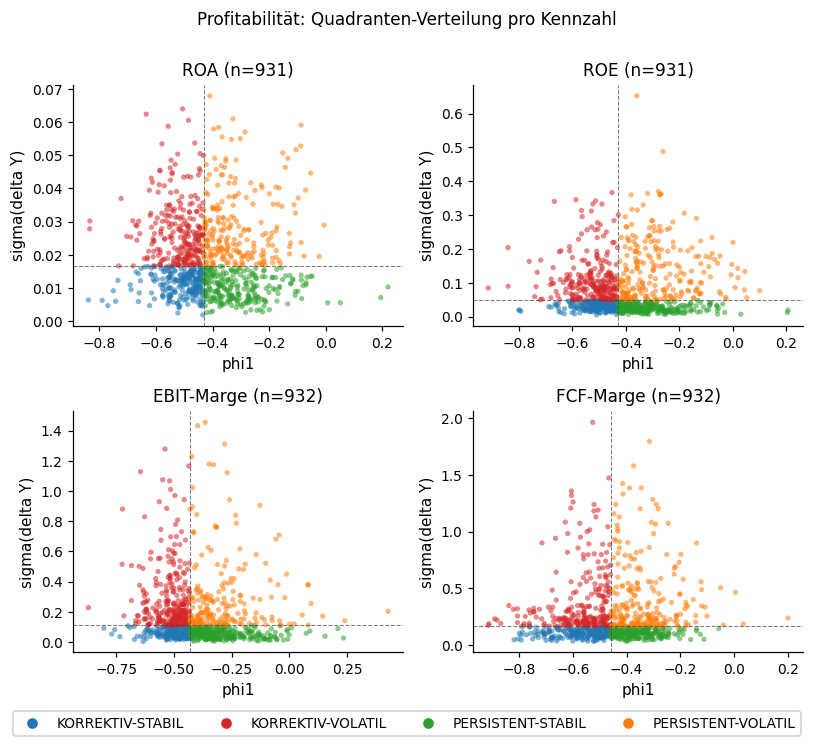

In [64]:
# Mini-Scatter pro Kennzahl, gefaerbt nach Quadrant
ratios_show = ['ROA', 'ROE', 'EBIT_margin', 'fcf_margin']
fig, axes = plt.subplots(2, 2, figsize=(7.5, 6.4),
                          squeeze=False)
for ax, r in zip(axes.flat, ratios_show):
    sub = ar_quad[ar_quad['ratio'] == r]
    for q in QUAD_ORDER:
        d = sub[sub['quadrant'] == q]
        ax.scatter(d['phi1'], d['sigma_diff'],
                    c=QUAD_COLORS[q], alpha=0.55, s=12,
                    edgecolors='none', label=f'{q} (n={len(d)})')
    ax.axvline(sub['phi1_median_used'].iloc[0], color='#444',
                linewidth=0.7, linestyle='--', alpha=0.7)
    ax.axhline(sub['sigma_median_used'].iloc[0], color='#444',
                linewidth=0.7, linestyle='--', alpha=0.7)
    ax.set_xlabel('phi1')
    ax.set_ylabel('sigma(delta Y)')
    ax.set_title(f'{RATIO_LABEL[r]} (n={len(sub)})')
# leere Achsen abschalten
for k in range(len(ratios_show), 2 * 2):
    axes[k // 2][k % 2].axis('off')
# Eine Legende fuer alle
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=QUAD_COLORS[q],
                       markersize=8, label=q) for q in QUAD_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.04),
            frameon=True, framealpha=0.92)
fig.suptitle('Profitabilität: Quadranten-Verteilung pro Kennzahl', fontsize=11, y=1.0)
plt.tight_layout()
plt.show()


In [65]:
prof_ratios = ["ROA","ROE","EBIT_margin","fcf_margin"]
ar_prof = ar[ar["ratio"].isin(prof_ratios)]
stats_prof = ah.compute_descriptive_stats(ar_prof, by="ratio",
                                           value_cols=("phi1","sigma_diff","r_squared"))
stats_prof = stats_prof.set_index(["ratio","value"]).reindex(
    pd.MultiIndex.from_product([prof_ratios, ["phi1","sigma_diff","r_squared"]],
                                names=["ratio","value"])
).reset_index().round(4)
stats_prof


,ratio,value,mean,median,std,iqr_low,iqr_high,p5,p95,n
0,ROA,phi1,-0.4135,-0.4311,0.1387,-0.5025,-0.3334,-0.6103,-0.1633,931
1,ROA,sigma_diff,0.0193,0.0166,0.0116,0.0108,0.0254,0.0058,0.0435,931
2,ROA,r_squared,0.1903,0.1872,0.1094,0.1103,0.2556,0.0278,0.3726,931
3,ROE,phi1,-0.4038,-0.4274,0.1512,-0.5033,-0.3123,-0.6099,-0.1209,931
4,ROE,sigma_diff,0.0789,0.0480,0.0771,0.0265,0.1030,0.0130,0.2422,931
5,ROE,r_squared,0.1853,0.1824,0.1125,0.0968,0.2535,0.0154,0.3734,931
6,EBIT_margin,phi1,-0.4007,-0.4309,0.1554,-0.5006,-0.3227,-0.6160,-0.1023,932
7,EBIT_margin,sigma_diff,0.1824,0.1107,0.2116,0.0567,0.2136,0.0223,0.6086,932
8,EBIT_margin,r_squared,0.1834,0.1862,0.1084,0.1022,0.2507,0.0119,0.3775,932
9,fcf_margin,phi1,-0.4586,-0.4586,0.1453,-0.5493,-0.3636,-0.7068,-0.2193,932


**Vergleichender Boxplot** — die vier Profitabilitätskennzahlen direkt nebeneinander:

/var/folders/99/50l4jq3j3f10cj2hwpl44xd80000gn/T/ipykernel_97541/485965618.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_p, labels=[RATIO_LABEL[r] for r in prof_ratios],
/var/folders/99/50l4jq3j3f10cj2hwpl44xd80000gn/T/ipykernel_97541/485965618.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(data_s, labels=[RATIO_LABEL[r] for r in prof_ratios],


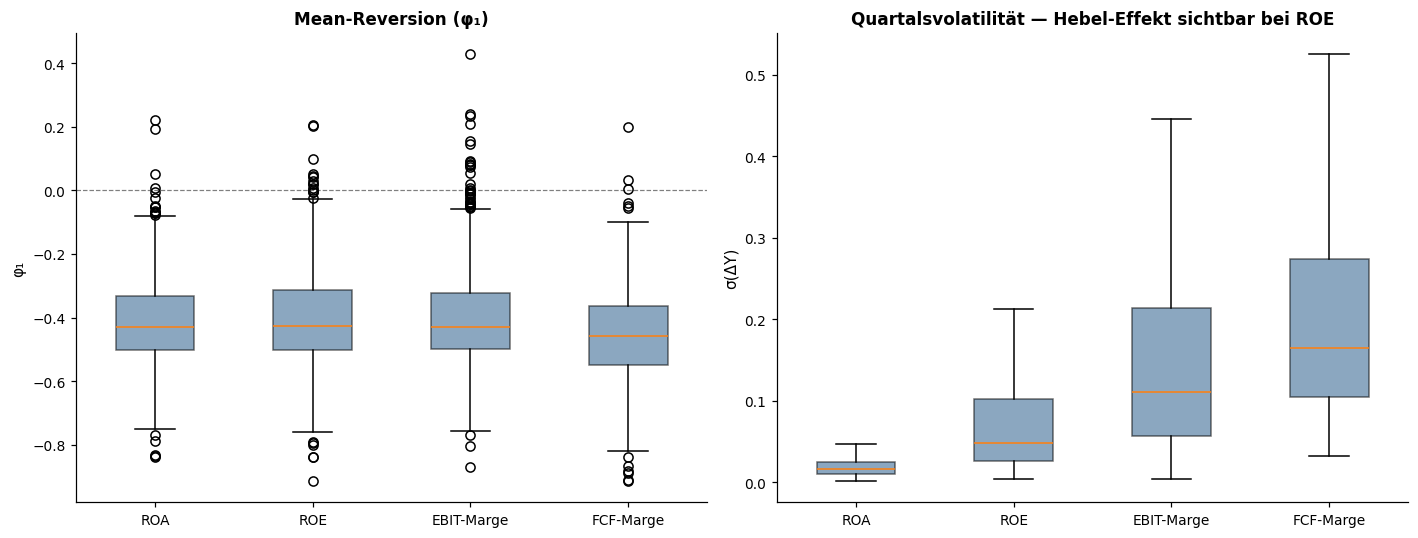

ROE σ-Median: 0.048 vs. ROA σ-Median: 0.0166 → Hebel-Faktor: 2.9


In [66]:
# Boxplot der 4 Profitabilitätskennzahlen — φ₁ und σ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

data_p = [ar[ar["ratio"]==r]["phi1"].dropna() for r in prof_ratios]
bp = ax1.boxplot(data_p, labels=[RATIO_LABEL[r] for r in prof_ratios],
                  patch_artist=True, widths=0.5)
for patch in bp["boxes"]:
    patch.set_facecolor(LAYER_COLORS["Profitabilität"]); patch.set_alpha(0.55)
ax1.axhline(0, color="black", ls="--", lw=0.8, alpha=0.5)
ax1.set_ylabel("φ₁"); ax1.set_title("Mean-Reversion (φ₁)", fontweight="bold")

data_s = [ar[ar["ratio"]==r]["sigma_diff"].dropna() for r in prof_ratios]
bp2 = ax2.boxplot(data_s, labels=[RATIO_LABEL[r] for r in prof_ratios],
                   patch_artist=True, widths=0.5, showfliers=False)
for patch in bp2["boxes"]:
    patch.set_facecolor(LAYER_COLORS["Profitabilität"]); patch.set_alpha(0.55)
ax2.set_ylabel("σ(ΔY)"); ax2.set_title("Quartalsvolatilität — Hebel-Effekt sichtbar bei ROE", fontweight="bold")

plt.tight_layout()
plt.show()
print("ROE σ-Median:", round(ar[ar['ratio']=='ROE']['sigma_diff'].median(), 4),
      "vs. ROA σ-Median:", round(ar[ar['ratio']=='ROA']['sigma_diff'].median(), 4),
      "→ Hebel-Faktor:", round(ar[ar['ratio']=='ROE']['sigma_diff'].median() / ar[ar['ratio']=='ROA']['sigma_diff'].median(), 2))


### 4.1.3 Liquiditätsgruppe

Übergangsfunktion zwischen Profitabilität und Kapitalstruktur. Current Ratio mit moderater Mean-Reversion (φ₁ = −0,17), Signifikanzrate nur 46 %.

**Konvention:** Lehrbuch-Zielspanne der Current Ratio liegt für gesunde Unternehmen bei 1,5–2,0 (Brealey/Myers/Allen).


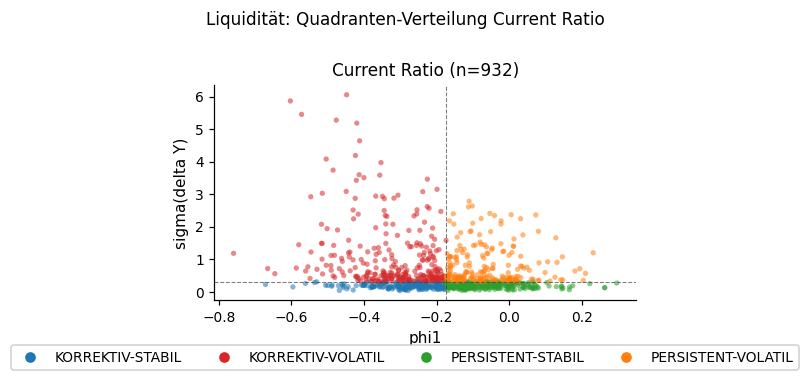

In [67]:
# Mini-Scatter pro Kennzahl, gefaerbt nach Quadrant
ratios_show = ['current_ratio']
fig, axes = plt.subplots(1, 1, figsize=(4.5, 3.2),
                          squeeze=False)
for ax, r in zip(axes.flat, ratios_show):
    sub = ar_quad[ar_quad['ratio'] == r]
    for q in QUAD_ORDER:
        d = sub[sub['quadrant'] == q]
        ax.scatter(d['phi1'], d['sigma_diff'],
                    c=QUAD_COLORS[q], alpha=0.55, s=12,
                    edgecolors='none', label=f'{q} (n={len(d)})')
    ax.axvline(sub['phi1_median_used'].iloc[0], color='#444',
                linewidth=0.7, linestyle='--', alpha=0.7)
    ax.axhline(sub['sigma_median_used'].iloc[0], color='#444',
                linewidth=0.7, linestyle='--', alpha=0.7)
    ax.set_xlabel('phi1')
    ax.set_ylabel('sigma(delta Y)')
    ax.set_title(f'{RATIO_LABEL[r]} (n={len(sub)})')
# leere Achsen abschalten
for k in range(len(ratios_show), 1 * 1):
    axes[k // 1][k % 1].axis('off')
# Eine Legende fuer alle
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=QUAD_COLORS[q],
                       markersize=8, label=q) for q in QUAD_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.04),
            frameon=True, framealpha=0.92)
fig.suptitle('Liquidität: Quadranten-Verteilung Current Ratio', fontsize=11, y=1.0)
plt.tight_layout()
plt.show()


In [68]:
liq_stats = ah.compute_descriptive_stats(ar[ar["ratio"]=="current_ratio"], by="ratio",
                                          value_cols=("phi1","sigma_diff","r_squared"))
liq_stats.round(4)


,ratio,value,mean,median,std,iqr_low,iqr_high,p5,p95,n
0,current_ratio,phi1,-0.1855,-0.1737,0.1588,-0.2919,-0.0733,-0.4596,0.0573,932
1,current_ratio,sigma_diff,0.6001,0.3175,0.7650,0.1871,0.6327,0.0933,2.2456,932
2,current_ratio,r_squared,0.0598,0.0323,0.0728,0.0078,0.0844,0.0003,0.2129,932


### 4.1.4 Kapitalstrukturgruppe

Nullbefund auf Differenzen mit eigenständigem Erkenntniswert: Kapitalstrukturveränderungen folgen keinem systematischen autoregressiven Prozess.

**Momentum-Subset:** Ein nennenswerter Anteil zeigt sogar positives φ₁.


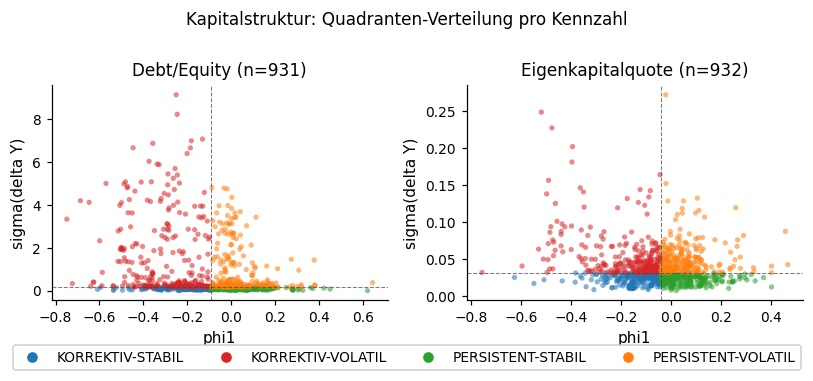

In [69]:
# Mini-Scatter pro Kennzahl, gefaerbt nach Quadrant
ratios_show = ['debt_to_equity', 'equity_ratio']
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.2),
                          squeeze=False)
for ax, r in zip(axes.flat, ratios_show):
    sub = ar_quad[ar_quad['ratio'] == r]
    for q in QUAD_ORDER:
        d = sub[sub['quadrant'] == q]
        ax.scatter(d['phi1'], d['sigma_diff'],
                    c=QUAD_COLORS[q], alpha=0.55, s=12,
                    edgecolors='none', label=f'{q} (n={len(d)})')
    ax.axvline(sub['phi1_median_used'].iloc[0], color='#444',
                linewidth=0.7, linestyle='--', alpha=0.7)
    ax.axhline(sub['sigma_median_used'].iloc[0], color='#444',
                linewidth=0.7, linestyle='--', alpha=0.7)
    ax.set_xlabel('phi1')
    ax.set_ylabel('sigma(delta Y)')
    ax.set_title(f'{RATIO_LABEL[r]} (n={len(sub)})')
# leere Achsen abschalten
for k in range(len(ratios_show), 1 * 2):
    axes[k // 2][k % 2].axis('off')
# Eine Legende fuer alle
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=QUAD_COLORS[q],
                       markersize=8, label=q) for q in QUAD_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.04),
            frameon=True, framealpha=0.92)
fig.suptitle('Kapitalstruktur: Quadranten-Verteilung pro Kennzahl', fontsize=11, y=1.0)
plt.tight_layout()
plt.show()


In [70]:
kap_stats = ah.compute_descriptive_stats(
    ar[ar["ratio"].isin(["debt_to_equity","equity_ratio"])], by="ratio",
    value_cols=("phi1","sigma_diff","r_squared")
)
kap_stats.round(4)


,ratio,value,mean,median,std,iqr_low,iqr_high,p5,p95,n
0,debt_to_equity,phi1,-0.1123,-0.0894,0.1919,-0.2346,0.0083,-0.4631,0.1662,931
1,debt_to_equity,sigma_diff,0.7437,0.1658,1.3289,0.0966,0.4673,0.0470,3.9425,931
2,debt_to_equity,r_squared,0.0501,0.0175,0.0779,0.0023,0.0635,0.0001,0.2204,931
3,equity_ratio,phi1,-0.0530,-0.0398,0.1573,-0.1304,0.0378,-0.3458,0.1828,932
4,equity_ratio,sigma_diff,0.0387,0.0314,0.0271,0.0237,0.0458,0.0134,0.0837,932
5,equity_ratio,r_squared,0.0276,0.0080,0.0521,0.0016,0.0262,0.0001,0.1294,932


In [71]:
# Momentum-Subset quantifizieren
momentum = ar.groupby("ratio")["phi1"].apply(lambda s: (s > 0).mean() * 100).round(1)
momentum.to_frame("Anteil mit φ₁ > 0 (%)").reindex(RATIO_ORDER)


,Anteil mit φ₁ > 0 (%)
ratio,
ROA,0.4
ROE,1.2
EBIT_margin,1.6
fcf_margin,0.3
current_ratio,11.4
debt_to_equity,28.1
equity_ratio,35.7


**Levels-vs-Differenzen-Asymmetrie** — Bilanzstruktur ist auf Levels hochpersistent (φ₁ ≈ 0,9), auf Differenzen quasi Null. Das ist konsistent: Bilanzen ändern sich selten, aber wenn sie es tun, ist die Änderung quasi-zufällig.

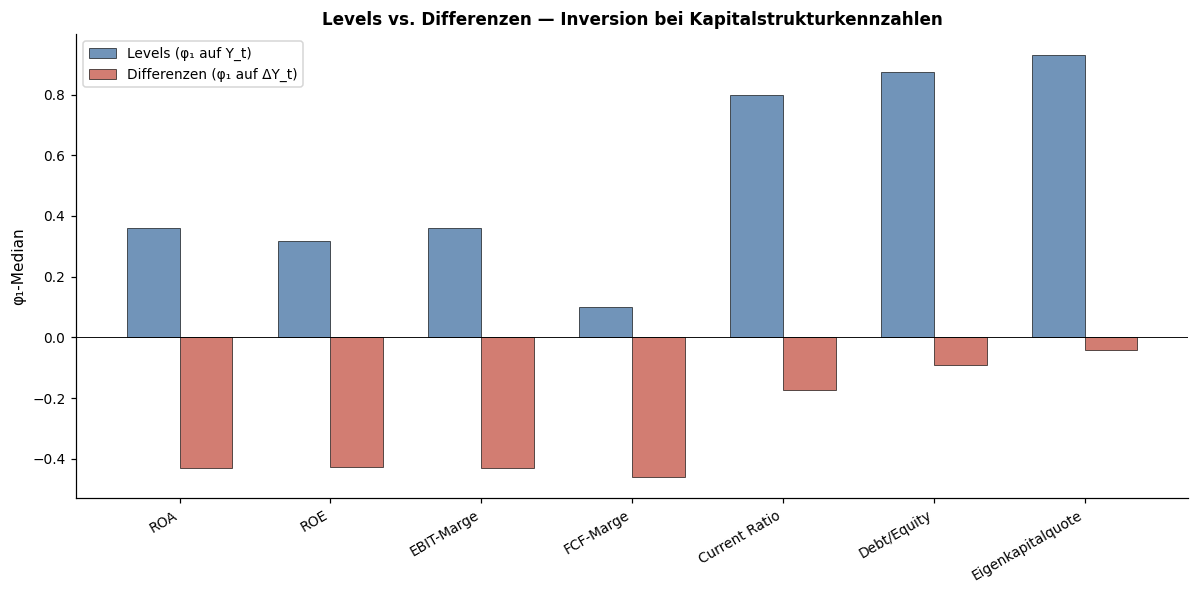

In [72]:
# Levels vs. Differenzen — Asymmetrie der Bilanzstruktur visuell
multi = ah.load_ar_summary_multimodel()
pivot = multi.pivot(index="ratio", columns="model", values="phi1_median").reindex(RATIO_ORDER)

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(RATIO_ORDER))
w = 0.35
ax.bar(x - w/2, pivot["levels"], w, label="Levels (φ₁ auf Y_t)",
       color="#4D7AA8", alpha=0.8, edgecolor="black", lw=0.5)
ax.bar(x + w/2, pivot["diff1"], w, label="Differenzen (φ₁ auf ΔY_t)",
       color="#C75D4F", alpha=0.8, edgecolor="black", lw=0.5)
ax.axhline(0, color="black", lw=0.6)
ax.set_xticks(x); ax.set_xticklabels([RATIO_LABEL[r] for r in RATIO_ORDER], rotation=30, ha="right")
ax.set_ylabel("φ₁-Median")
ax.set_title("Levels vs. Differenzen — Inversion bei Kapitalstrukturkennzahlen", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


---
## 4.2 Analyse nach Branche


In [ ]:
# Abb. 4.7 — Branchen-IQR-Rechtecke pro Dynamiktyp (Aufhänger 4.2)
# Hauptkennzahl pro Dynamiktyp: ROA / Current Ratio / Eigenkapitalquote
# Globaler Median (alle 7 Kennzahlen, alle Unternehmen) als gestricheltes Linien-Paar
import matplotlib.colors as mcolors

SECTOR_DE = {
    "Industrials": "Industrie", "Consumer Cyclical": "Zykl. Konsum",
    "Technology": "Technologie", "Healthcare": "Gesundheit",
    "Utilities": "Versorger", "Consumer Defensive": "Basis Konsum",
    "Basic Materials": "Grundstoffe", "Real Estate": "Immobilien",
    "Energy": "Energie", "Communication Services": "Komm.-dienste",
}
_cmap10 = plt.get_cmap("tab10")
SECTOR_COLORS = {sec: _cmap10(i) for i, sec in enumerate(SECTOR_ORDER)}

ar_sec = ah.attach_sector(ah.load_ar_features())
ar_sec = ar_sec[(ar_sec["sector"].notna()) & (ar_sec["sector"] != "Other")]
ar_sec = ar_sec.dropna(subset=["phi1", "sigma_diff"])

GROUPS_IQR = [
    ("Profitabilität (ROA)",                "ROA"),
    ("Liquidität (Current Ratio)",          "current_ratio"),
    ("Kapitalstruktur (Eigenkapitalquote)", "equity_ratio"),
]

# Globaler Median über alle 7 Hauptkennzahlen
ALL_RATIOS = ["ROA","ROE","EBIT_margin","fcf_margin","current_ratio","debt_to_equity","equity_ratio"]
all_ar = ar_sec[ar_sec["ratio"].isin(ALL_RATIOS)]
phi_med_global = all_ar["phi1"].median()
sig_med_global = all_ar["sigma_diff"].median()

fig, ax = plt.subplots(1, 1, figsize=(13, 7.5))
all_phi, all_sig = [], []

for group_label, ratio in GROUPS_IQR:
    sub = ar_sec[ar_sec["ratio"] == ratio]
    for sector in SECTOR_ORDER:
        sec_data = sub[sub["sector"] == sector]
        if len(sec_data) < 5:
            continue
        phi_q1, phi_q3 = sec_data["phi1"].quantile([0.25, 0.75])
        sig_q1, sig_q3 = sec_data["sigma_diff"].quantile([0.25, 0.75])
        if sig_q1 <= 0:
            sig_q1 = sec_data["sigma_diff"][sec_data["sigma_diff"] > 0].min()
        col = SECTOR_COLORS[sector]
        rect = mpatches.Rectangle(
            (phi_q1, sig_q1), phi_q3 - phi_q1, sig_q3 - sig_q1,
            facecolor=mcolors.to_rgba(col, alpha=0.15),
            edgecolor=mcolors.to_rgba(col, alpha=1.0),
            linewidth=2.0, alpha=None,
        )
        ax.add_patch(rect)
        all_phi.extend([phi_q1, phi_q3])
        all_sig.extend([sig_q1, sig_q3])

ax.axvline(phi_med_global, color="black", linestyle="--", linewidth=1.0, alpha=0.7, zorder=10)
ax.axhline(sig_med_global, color="black", linestyle="--", linewidth=1.0, alpha=0.7, zorder=10)

ax.set_xlabel(r"$\varphi_1$", fontsize=12)
ax.set_ylabel(r"$\sigma(\Delta Y)$", fontsize=12)
ax.set_yscale("log")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--", alpha=0.5)
ax.set_xlim(min(all_phi) - 0.05, max(all_phi) + 0.05)
ax.set_ylim(min(all_sig) * 0.7, max(all_sig) * 1.5)

sector_handles = [
    mpatches.Patch(facecolor=SECTOR_COLORS[sec], edgecolor=SECTOR_COLORS[sec],
                    linewidth=1.2, alpha=0.6, label=SECTOR_DE[sec])
    for sec in SECTOR_ORDER
]
median_handle = plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.2,
                            label="Globaler Median (alle Kennzahlen)")
fig.legend(handles=sector_handles + [median_handle], loc="lower center", ncol=6,
            frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.08, 1, 0.97])
fig.savefig(ROOT / "output/plots/ff1_iqr_aufhaenger.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
# IQR-Aufhänger-Variante mit anpassbarem Quantil-Paar
# (q_low, q_high) ändern, um die Branchen-Boxen für andere Perzentile zu sehen.
# Beispiele:
#   (0.25, 0.75)  → IQR (Default, identisch zu Abb. 4.7)
#   (0.10, 0.90)  → 80-%-Bereich
#   (0.40, 0.60)  → engerer 20-%-Kernbereich
import matplotlib.colors as mcolors

# === Parameter ===
q_low, q_high = 0.25, 0.75    # ← hier anpassen
# ==================

GROUPS_VAR = [
    ("Profitabilität (ROA)",                "ROA"),
    ("Liquidität (Current Ratio)",          "current_ratio"),
    ("Kapitalstruktur (Eigenkapitalquote)", "equity_ratio"),
]

ar_var = ah.attach_sector(ah.load_ar_features())
ar_var = ar_var[(ar_var["sector"].notna()) & (ar_var["sector"] != "Other")]
ar_var = ar_var.dropna(subset=["phi1", "sigma_diff"])

ALL_RATIOS = ["ROA","ROE","EBIT_margin","fcf_margin","current_ratio","debt_to_equity","equity_ratio"]
all_ar_var = ar_var[ar_var["ratio"].isin(ALL_RATIOS)]
phi_med_global = all_ar_var["phi1"].median()
sig_med_global = all_ar_var["sigma_diff"].median()

fig, ax = plt.subplots(1, 1, figsize=(13, 7.5))
all_phi, all_sig = [], []

for group_label, ratio in GROUPS_VAR:
    sub = ar_var[ar_var["ratio"] == ratio]
    for sector in SECTOR_ORDER:
        sec_data = sub[sub["sector"] == sector]
        if len(sec_data) < 5:
            continue
        phi_lo, phi_hi = sec_data["phi1"].quantile([q_low, q_high])
        sig_lo, sig_hi = sec_data["sigma_diff"].quantile([q_low, q_high])
        if sig_lo <= 0:
            sig_lo = sec_data["sigma_diff"][sec_data["sigma_diff"] > 0].min()
        col = SECTOR_COLORS[sector]
        rect = mpatches.Rectangle(
            (phi_lo, sig_lo), phi_hi - phi_lo, sig_hi - sig_lo,
            facecolor=mcolors.to_rgba(col, alpha=0.15),
            edgecolor=mcolors.to_rgba(col, alpha=1.0),
            linewidth=2.0, alpha=None,
        )
        ax.add_patch(rect)
        all_phi.extend([phi_lo, phi_hi])
        all_sig.extend([sig_lo, sig_hi])

ax.axvline(phi_med_global, color="black", linestyle="--", linewidth=1.0, alpha=0.7, zorder=10)
ax.axhline(sig_med_global, color="black", linestyle="--", linewidth=1.0, alpha=0.7, zorder=10)

ax.set_xlabel(r"$\varphi_1$", fontsize=12)
ax.set_ylabel(r"$\sigma(\Delta Y)$", fontsize=12)
ax.set_yscale("log")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--", alpha=0.5)
ax.set_xlim(min(all_phi) - 0.05, max(all_phi) + 0.05)
ax.set_ylim(min(all_sig) * 0.7, max(all_sig) * 1.5)

ax.set_title(f"Branchen-Quantil-Boxen pro Dynamiktyp "
              f"(Q{int(q_low*100)} bis Q{int(q_high*100)}, "
              f"abdeckt {int((q_high-q_low)*100)} % der Werte pro Achse)",
              fontsize=11)

sector_handles = [
    mpatches.Patch(facecolor=SECTOR_COLORS[sec], edgecolor=SECTOR_COLORS[sec],
                    linewidth=1.2, alpha=0.6, label=SECTOR_DE[sec])
    for sec in SECTOR_ORDER
]
median_handle = plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.2,
                            label="Globaler Median (alle Kennzahlen)")
fig.legend(handles=sector_handles + [median_handle], loc="lower center", ncol=6,
            frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.08, 1, 0.97])
plt.show()


### 4.2.1 Sektorale Übersicht der AR(1)-Kenngrößen

Drei Tabellen für drei Perspektiven: φ₁-Median, σ-Median, Signifikanzrate. Jeweils Sektor × Kennzahl.


In [ ]:
# Mini-Scatter pro Dynamiktyp: zehn Branchen-Punkte mit Median-Linien als Quadranten-Gitter
# Farben konsistent zu Abb. 4.7 (tab10), Direkt-Labels mit manuellen Offsets
# Innerhalb einer Dynamiktyp-Gruppe feste φ-Achse, σ-Achse pro Plot frei
from matplotlib.ticker import MaxNLocator

RATIO_LABEL_DE = {
    "ROA": "ROA", "ROE": "ROE", "EBIT_margin": "EBIT-Marge",
    "fcf_margin": "FCF-Marge", "current_ratio": "Current Ratio",
    "debt_to_equity": "Debt/Equity", "equity_ratio": "Eigenkapitalquote",
}

GROUPS_MINI = {
    "Profitabilität":   (["ROA", "ROE", "EBIT_margin", "fcf_margin"], (2, 2), (-0.56, -0.35)),
    "Liquidität":       (["current_ratio"],                            (1, 1), None),
    "Kapitalstruktur":  (["debt_to_equity", "equity_ratio"],           (1, 2), (-0.18, 0.01)),
}

DEFAULT_OFFSET = (7, 5)
LABEL_OFFSETS = {
    "ROA": {
        "Consumer Cyclical":  (7, -10),
        "Industrials":        (2, -10),
        "Technology":         (-30, 8),
        "Basic Materials":    (-30, 8),
    },
    "ROE": {
        "Utilities":          (7, -10),
        "Technology":         (-30, 8),
        "Basic Materials":    (-30, 8),
        "Industrials":        (-20, 8),
    },
    "EBIT_margin": {
        "Communication Services": (-5, 5),
        "Healthcare":             (-20, 5),
        "Consumer Defensive":     (-30, 8),
        "Consumer Cyclical":      (-30, 8),
        "Technology":             (-30, 8),
    },
    "fcf_margin": {
        "Communication Services": (-30, 8),
        "Healthcare":             (7, -10),
        "Industrials":            (-30, -10),
        "Consumer Cyclical":      (-30, 8),
        "Consumer Defensive":     (7, -10),
    },
    "current_ratio": {
        "Industrials":            (7,  8),
        "Communication Services": (7, -8),
        "Consumer Defensive":     (7, -10),
        "Utilities":              (-30, -3),
        "Basic Materials":        (7, -8),
        "Consumer Cyclical":      (-30, 8),
    },
    "debt_to_equity": {
        "Basic Materials": (7,  8),
        "Technology":      (7, -8),
    },
    "equity_ratio": {
        "Industrials":            (7,  8),
        "Communication Services": (7, -5),
        "Consumer Cyclical":      (7, -12),
        "Healthcare":             (7, 15),
    },
}

ar_for_mini = ah.attach_sector(ah.load_ar_features())
ar_for_mini = ar_for_mini[(ar_for_mini["sector"].notna()) & (ar_for_mini["sector"] != "Other")]

for group_name, (ratios, (nrow, ncol), phi_range) in GROUPS_MINI.items():
    fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 4.2*nrow), squeeze=False)
    for idx, ratio in enumerate(ratios):
        ax = axes.flat[idx]
        sub = ar_for_mini[ar_for_mini["ratio"] == ratio].dropna(subset=["phi1", "sigma_diff"])
        med = sub.groupby("sector").agg(phi1=("phi1", "median"),
                                         sigma=("sigma_diff", "median")).reset_index()
        med = med[med["sector"].isin(SECTOR_DE.keys())]
        phi_glob = sub["phi1"].median()
        sig_glob = sub["sigma_diff"].median()

        offsets_for_ratio = LABEL_OFFSETS.get(ratio, {})
        for _, row in med.iterrows():
            col = SECTOR_COLORS[row["sector"]]
            ax.scatter(row["phi1"], row["sigma"], s=85, color=col,
                        edgecolor="black", linewidth=0.4, zorder=3)
            dx, dy = offsets_for_ratio.get(row["sector"], DEFAULT_OFFSET)
            ax.annotate(SECTOR_DE[row["sector"]], (row["phi1"], row["sigma"]),
                         xytext=(dx, dy), textcoords="offset points",
                         fontsize=8, zorder=4)

        ax.axvline(phi_glob, color="grey", linestyle="--", linewidth=1.0, alpha=0.7)
        ax.axhline(sig_glob, color="grey", linestyle="--", linewidth=1.0, alpha=0.7)
        if phi_range is not None:
            ax.set_xlim(*phi_range)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.grid(True, color="lightgrey", linestyle="-", linewidth=0.4, alpha=0.4, zorder=1)
        ax.set_axisbelow(True)
        ax.set_xlabel(r"$\varphi_1$-Median")
        ax.set_ylabel(r"$\sigma(\Delta Y)$-Median")
        ax.set_title(RATIO_LABEL_DE[ratio])
    for j in range(len(ratios), nrow*ncol):
        axes.flat[j].axis("off")
    fig.suptitle(f"Branchen-Mediane im $\\varphi_1$-$\\sigma$-Raum: {group_name}",
                  fontsize=11)
    fig.tight_layout()
    plt.show()


In [75]:
ar_with_sec = ah.attach_sector(ar)

# Tab. 4.3 — φ₁-Median
phi1_pivot = ah.compute_sector_pivot(ar_with_sec, "phi1", "median")
phi1_pivot.round(3)


ratio,ROA,ROE,EBIT_margin,fcf_margin,current_ratio,debt_to_equity,equity_ratio
sector,,,,,,,
Industrials,-0.434,-0.434,-0.431,-0.469,-0.168,-0.076,-0.034
Consumer Cyclical,-0.402,-0.406,-0.396,-0.479,-0.198,-0.043,-0.025
Technology,-0.400,-0.395,-0.392,-0.453,-0.098,-0.048,-0.023
Healthcare,-0.447,-0.426,-0.449,-0.464,-0.163,-0.105,-0.051
Utilities,-0.428,-0.428,-0.461,-0.502,-0.177,-0.171,-0.144
Consumer Defensive,-0.431,-0.441,-0.451,-0.450,-0.159,-0.155,-0.090
Basic Materials,-0.372,-0.394,-0.431,-0.382,-0.161,-0.050,-0.005
Real Estate,-0.468,-0.463,-0.473,-0.476,-0.343,-0.167,-0.078
Energy,-0.434,-0.438,-0.418,-0.433,-0.230,-0.090,-0.067


In [76]:
# Tab. 4.3b — σ-Median
sigma_pivot = ah.compute_sector_pivot(ar_with_sec, "sigma_diff", "median")
sigma_pivot.round(3)


ratio,ROA,ROE,EBIT_margin,fcf_margin,current_ratio,debt_to_equity,equity_ratio
sector,,,,,,,
Industrials,0.015,0.038,0.068,0.125,0.265,0.136,0.029
Consumer Cyclical,0.018,0.062,0.082,0.145,0.235,0.234,0.029
Technology,0.019,0.051,0.108,0.160,0.403,0.139,0.038
Healthcare,0.020,0.069,0.118,0.147,0.520,0.167,0.040
Utilities,0.011,0.038,0.158,0.222,0.201,0.145,0.016
Consumer Defensive,0.015,0.044,0.055,0.095,0.215,0.157,0.029
Basic Materials,0.020,0.046,0.130,0.177,0.472,0.140,0.033
Real Estate,0.011,0.031,0.218,0.601,1.343,0.251,0.027
Energy,0.024,0.078,0.259,0.250,0.347,0.179,0.040


In [77]:
# Tab. 4.3c — Signifikanzrate
sig_pivot = ah.compute_signif_rate_by_sector(ar_with_sec)
sig_pivot.round(0).astype(int)


ratio,ROA,ROE,EBIT_margin,fcf_margin,current_ratio,debt_to_equity,equity_ratio
sector,,,,,,,
Industrials,94,92,90,95,39,26,15
Consumer Cyclical,86,86,87,97,53,33,15
Technology,93,88,84,98,34,27,18
Healthcare,98,93,93,99,43,37,21
Utilities,87,89,90,93,47,49,26
Consumer Defensive,91,90,94,94,41,34,22
Basic Materials,87,81,85,94,40,25,13
Real Estate,98,95,95,100,82,45,24
Energy,94,92,92,98,55,30,29


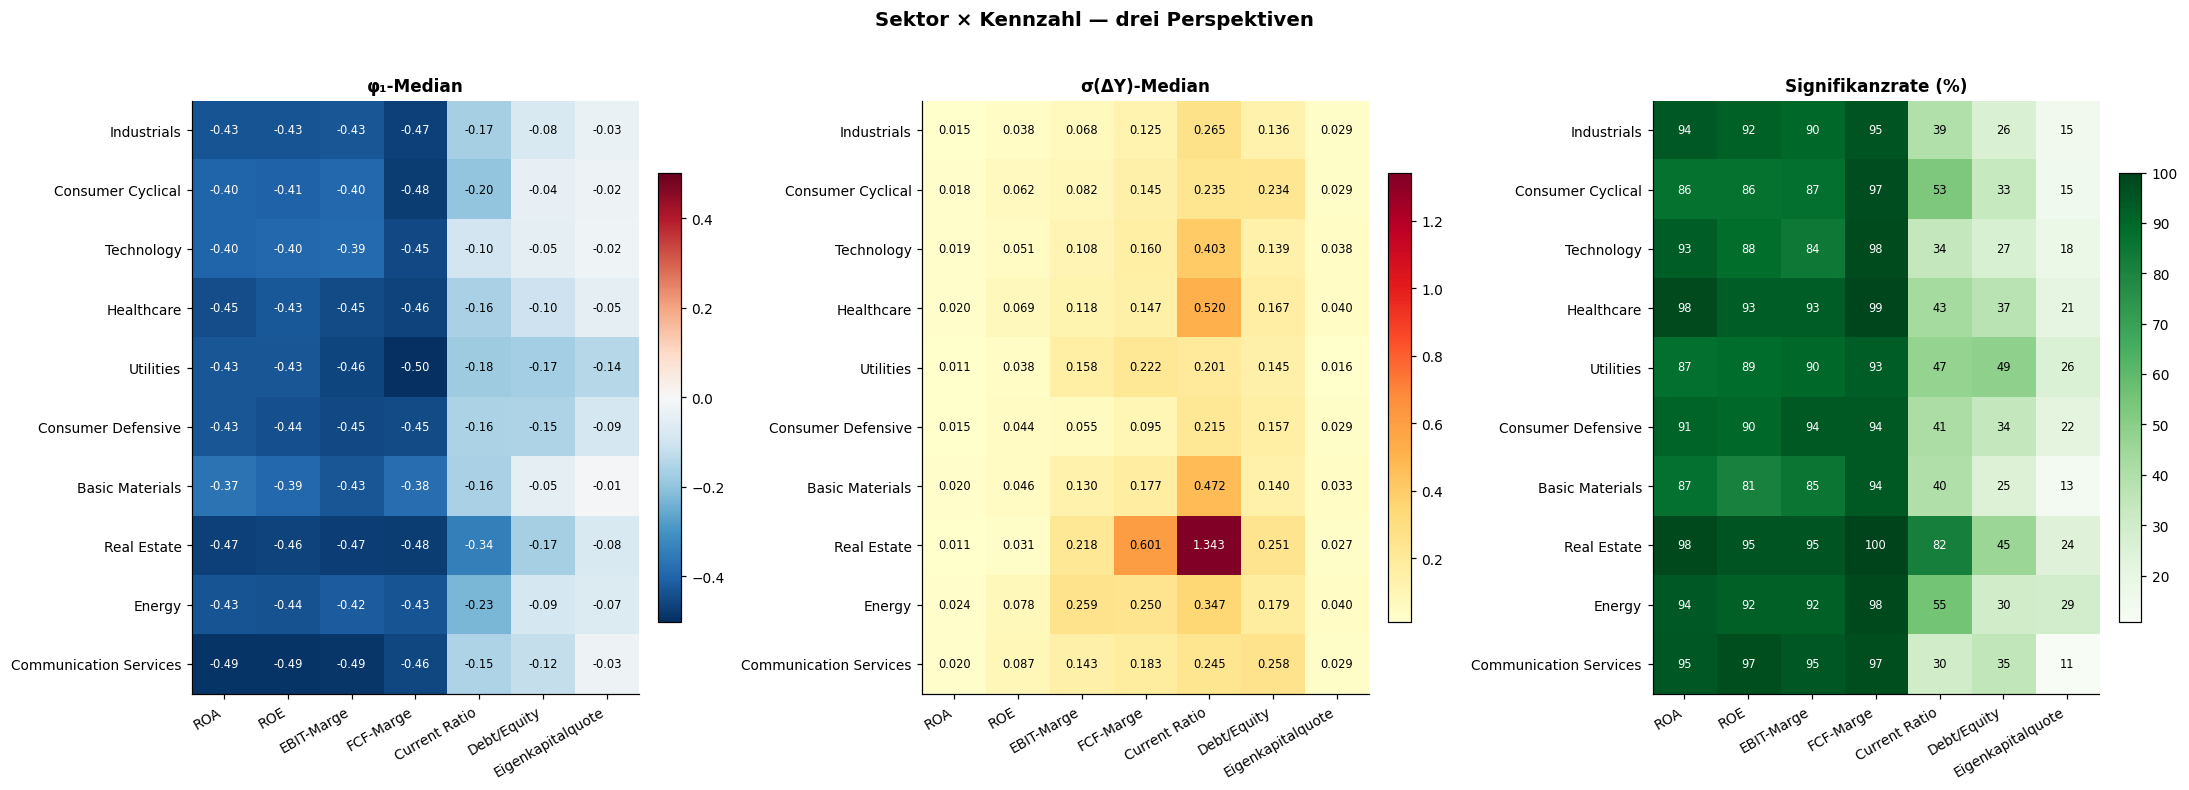

In [78]:
# Drei Heatmaps Sektor × Kennzahl
def plot_sector_heatmap(ax, pivot, title, cmap, fmt=".2f", center=None):
    data = pivot.values
    vmin = -abs(data[~np.isnan(data)]).max() if center is not None else None
    vmax = abs(data[~np.isnan(data)]).max() if center is not None else None
    im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels([RATIO_LABEL[c] for c in pivot.columns], rotation=30, ha="right")
    ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = data[i,j]
            if not np.isnan(v):
                color = "white" if abs(v) > abs(data[~np.isnan(data)]).max()*0.6 else "black"
                ax.text(j, i, f"{v:{fmt}}", ha="center", va="center", fontsize=7.5, color=color)
    ax.set_title(title, fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
plot_sector_heatmap(axes[0], phi1_pivot.iloc[:10], "φ₁-Median", "RdBu_r", center=0)
plot_sector_heatmap(axes[1], sigma_pivot.iloc[:10], "σ(ΔY)-Median", "YlOrRd", fmt=".3f")
plot_sector_heatmap(axes[2], sig_pivot.iloc[:10], "Signifikanzrate (%)", "Greens", fmt=".0f")
fig.suptitle("Sektor × Kennzahl — drei Perspektiven", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Optional — sektorspezifische φ₁-KDEs.** Pro Sektor eine Detailverteilung. Default: nicht ausgeführt (Cell auskommentiert), bei Bedarf entkommentieren.

In [79]:
# Sektorspezifische KDE-Plots — entkommentieren wenn gewünscht
# fig, axes = plt.subplots(3, 4, figsize=(16, 10))
# axes = axes.flatten()
# for i, sector in enumerate(SECTOR_ORDER):
#     ax = axes[i]
#     sub_sec = ar_with_sec[ar_with_sec["sector"]==sector]
#     for ratio in RATIO_ORDER:
#         vals = sub_sec[sub_sec["ratio"]==ratio]["phi1"].dropna()
#         if len(vals) < 10: continue
#         color = LAYER_COLORS[RATIO_LAYER[ratio]]
#         kde = stats.gaussian_kde(vals)
#         xx = np.linspace(-1, 0.5, 200)
#         ax.plot(xx, kde(xx), color=color, lw=1.3, alpha=0.7,
#                 label=RATIO_LABEL[ratio])
#     ax.axvline(0, color="black", ls="--", lw=0.6, alpha=0.5)
#     ax.set_title(f"{sector} (n={len(sub_sec['ticker'].unique())})", fontweight="bold")
#     ax.set_xlabel("φ₁")
# axes[10].axis("off"); axes[11].axis("off")
# fig.suptitle("Sektorspezifische φ₁-Verteilungen", fontsize=13, fontweight="bold")
# plt.tight_layout()
# plt.show()


### 4.2.2 Quadrantenverteilung pro Sektor

Jedes Unternehmen wird über die 7 Kennzahlen einem dominanten Quadranten zugeordnet.


In [ ]:
# Abb. 4.X — Branchen-Quadranten-Heatmap
# Pro Branche × Kennzahl: Δφ und Δσ (Abstand vom Stichproben-Median).
# Vorzeichen-Kombination klassifiziert in vier Quadranten (KS/KV/PS/PV, siehe Legende),
# Sättigung der Farbe ∝ Magnitude (normiert pro Kennzahl).
# Pro Zelle: oben links = % der Branchen-Unternehmen im Median-Quadranten;
#            oben rechts = % signifikant (p<0,05).
# Branchen sortiert nach mittlerer Magnitude (oben am wenigsten farbig).
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

SECTOR_DE = {
    "Industrials": "Industrie", "Consumer Cyclical": "Zykl. Konsum",
    "Technology": "Technologie", "Healthcare": "Gesundheit",
    "Utilities": "Versorger", "Consumer Defensive": "Basis Konsum",
    "Basic Materials": "Grundstoffe", "Real Estate": "Immobilien",
    "Energy": "Energie", "Communication Services": "Komm.-dienste",
}
RATIO_DE_SHORT = {
    "ROA":"ROA", "ROE":"ROE", "EBIT_margin":"EBIT-Marge",
    "fcf_margin":"FCF-Marge", "current_ratio":"Current Ratio",
    "debt_to_equity":"Debt/Equity", "equity_ratio":"EK-Quote",
}

ar_q = ah.attach_sector(ah.load_ar_features())
ar_q = ar_q[(ar_q["sector"].notna()) & (ar_q["sector"] != "Other")]
ar_q = ar_q[ar_q["ratio"].isin(RATIO_ORDER)].dropna(subset=["phi1", "sigma_diff"])

ratio_phi_med = ar_q.groupby("ratio")["phi1"].median()
ratio_sig_med = ar_q.groupby("ratio")["sigma_diff"].median()

def unt_quadrant(row):
    dphi = row["phi1"] - ratio_phi_med[row["ratio"]]
    dsig = row["sigma_diff"] - ratio_sig_med[row["ratio"]]
    if dphi < 0 and dsig < 0: return "KS"
    if dphi < 0 and dsig >= 0: return "KV"
    if dphi >= 0 and dsig < 0: return "PS"
    return "PV"
ar_q["unt_q"] = ar_q.apply(unt_quadrant, axis=1)

rows = []
for sec in SECTOR_ORDER:
    for r in RATIO_ORDER:
        sub = ar_q[(ar_q["sector"]==sec) & (ar_q["ratio"]==r)]
        if len(sub) < 5: continue
        phi_b = sub["phi1"].median()
        sig_b = sub["sigma_diff"].median()
        d_phi = phi_b - ratio_phi_med[r]
        d_sig = sig_b - ratio_sig_med[r]
        # Median-Quadrant: wo der Branchen-Median relativ zum Stichproben-Median liegt
        if d_phi < 0 and d_sig < 0: q_median = "KS"
        elif d_phi < 0 and d_sig >= 0: q_median = "KV"
        elif d_phi >= 0 and d_sig < 0: q_median = "PS"
        else: q_median = "PV"
        # Modus-Quadrant: der Quadrant mit den meisten Unternehmen
        q_counts = {qq: (sub["unt_q"] == qq).sum() for qq in ["KS", "KV", "PS", "PV"]}
        q = max(q_counts, key=q_counts.get)
        pct_in_q = (sub["unt_q"] == q).mean() * 100
        pct_in_q_sig = ((sub["unt_q"] == q) & (sub["phi1_pval"] < 0.05)).mean() * 100
        median_in_mode = (q_median == q)
        rows.append({"sector": sec, "ratio": r, "d_phi": d_phi, "d_sig": d_sig,
                      "q": q, "q_median": q_median,
                      "pct_in_q": pct_in_q, "pct_in_q_sig": pct_in_q_sig,
                      "median_in_mode": median_in_mode})
df_q = pd.DataFrame(rows)

df_q["d_phi_norm"] = df_q.groupby("ratio")["d_phi"].transform(lambda s: s/s.abs().max())
df_q["d_sig_norm"] = df_q.groupby("ratio")["d_sig"].transform(lambda s: s/s.abs().max())
df_q["mag"] = np.sqrt(df_q["d_phi_norm"]**2 + df_q["d_sig_norm"]**2) / np.sqrt(2)

QUAD_COLORS = {"KS": (0.18, 0.40, 0.66), "KV": (0.78, 0.20, 0.20),
                "PS": (0.18, 0.55, 0.34), "PV": (0.95, 0.62, 0.10)}

def cell_color(q, intensity):
    base = np.array(QUAD_COLORS[q])
    white = np.array([1.0, 1.0, 1.0])
    return white * (1 - intensity) + base * intensity

def sat_from_pct(pct):
    """Sättigung aus %-im-Quadranten: 25% = blass (Gleichverteilung), 100% = voll satt."""
    return max(0, min(1, (pct - 25) / 75))

mag_per_sector = df_q.groupby("sector")["mag"].mean().sort_values()
sec_list = mag_per_sector.index.tolist()
ratio_list = RATIO_ORDER
n_sec, n_rat = len(sec_list), len(ratio_list)

fig, ax = plt.subplots(1, 1, figsize=(14, 9.5))
for i, sec in enumerate(sec_list):
    for j, r in enumerate(ratio_list):
        sub = df_q[(df_q["sector"]==sec) & (df_q["ratio"]==r)]
        if len(sub) == 0: continue
        row = sub.iloc[0]
        col = cell_color(row["q"], sat_from_pct(row["pct_in_q"]))
        ax.add_patch(plt.Rectangle((j, n_sec-1-i), 1, 1,
                                     facecolor=col, edgecolor="white", linewidth=1.5))
        ax.text(j+0.05, n_sec-1-i+0.92, f'{row["pct_in_q"]:.0f}%',
                 ha="left", va="top", fontsize=9, color="black")
        ax.text(j+0.95, n_sec-1-i+0.92, f'{row["pct_in_q_sig"]:.0f}%',
                 ha="right", va="top", fontsize=9, color="black")
        if row["median_in_mode"]:
            ax.text(j+0.5, n_sec-1-i+0.92, "★",
                     ha="center", va="top", fontsize=9, color="black")
        ax.text(j+0.5, n_sec-1-i+0.42, f'Δφ {row["d_phi"]:+.3f}',
                 ha="center", va="center", fontsize=9, color="black")
        ax.text(j+0.5, n_sec-1-i+0.18, f'Δσ {row["d_sig"]:+.3f}',
                 ha="center", va="center", fontsize=9, color="black")

ax.set_xlim(0, n_rat)
ax.set_ylim(0, n_sec)
ax.set_xticks(np.arange(n_rat) + 0.5)
ax.set_xticklabels([RATIO_DE_SHORT[r] for r in ratio_list], fontsize=10, rotation=30, ha="right")
ax.set_yticks(np.arange(n_sec) + 0.5)
ax.set_yticklabels([SECTOR_DE[s] for s in reversed(sec_list)], fontsize=10)
ax.set_aspect("equal")
ax.tick_params(axis="both", length=0)

handles = [
    mpatches.Patch(color=QUAD_COLORS["KV"], label="Korrektiv-Volatil  (φ↓ σ↑)"),
    mpatches.Patch(color=QUAD_COLORS["KS"], label="Korrektiv-Stabil  (φ↓ σ↓)"),
    mpatches.Patch(color=QUAD_COLORS["PV"], label="Persistent-Volatil  (φ↑ σ↑)"),
    mpatches.Patch(color=QUAD_COLORS["PS"], label="Persistent-Stabil  (φ↑ σ↓)"),
]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False,
            fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(ROOT / "output/plots/ff1_branchen_quadranten.png", dpi=170, bbox_inches="tight")
df_q.to_csv(ROOT / "output/ar/branchen_quadranten_delta.csv", index=False)
plt.show()


In [80]:
profiles = ah.load_company_profiles()
prof_clean = profiles.dropna(subset=["sector","dominant_quadrant"])
quad_pivot = pd.crosstab(prof_clean["sector"], prof_clean["dominant_quadrant"], normalize="index") * 100
avail = [s for s in SECTOR_ORDER if s in quad_pivot.index]
quad_pivot = quad_pivot.reindex(avail)
quad_pivot.round(1)


dominant_quadrant,KORREKTIV-STABIL,KORREKTIV-VOLATIL,PERSISTENT-STABIL,PERSISTENT-VOLATIL
sector,,,,
Industrials,28.0,19.2,37.8,15.0
Consumer Cyclical,17.3,25.6,35.3,21.8
Technology,14.2,22.8,27.6,35.4
Healthcare,25.5,21.4,20.4,32.7
Utilities,37.1,15.7,40.0,7.1
Consumer Defensive,35.3,23.5,33.8,7.4
Basic Materials,10.3,27.9,30.9,30.9
Real Estate,18.2,53.0,18.2,10.6
Energy,6.2,46.2,20.0,27.7


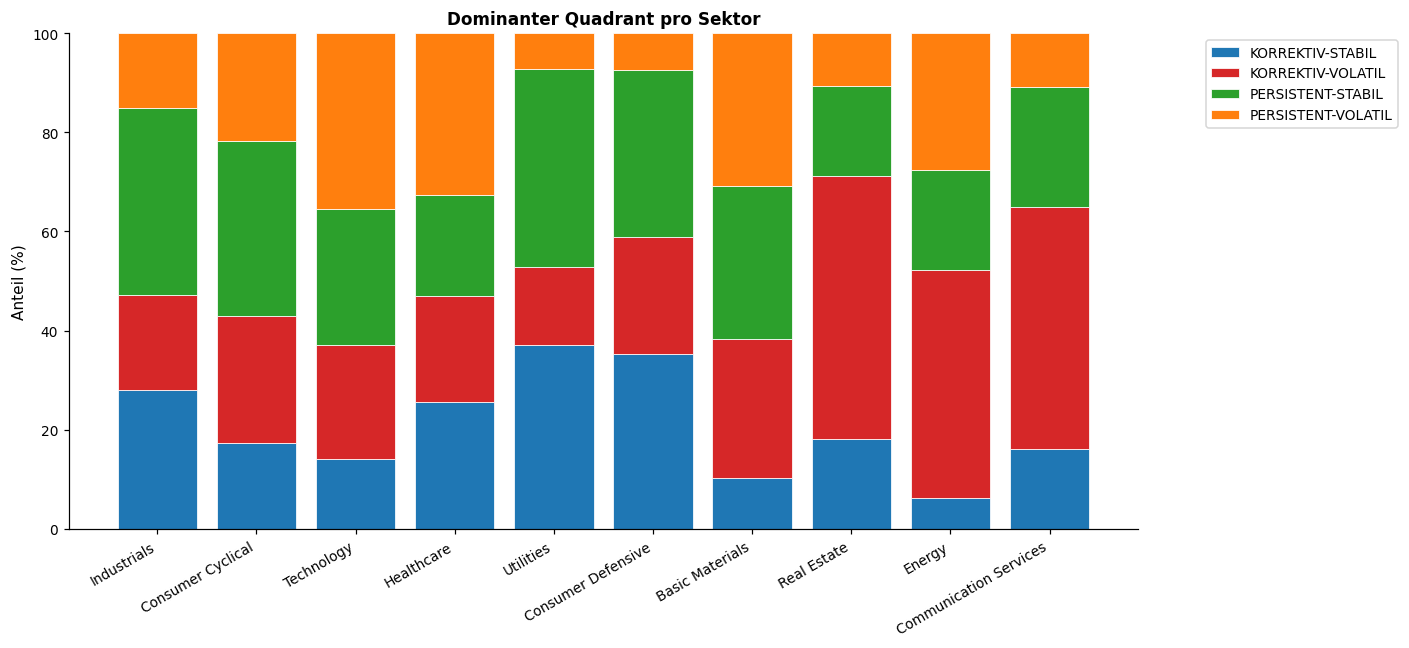

In [81]:
# Quadrantenverteilung pro Sektor — gestapelte Säulen
fig, ax = plt.subplots(figsize=(13, 6))
quads_in_order = ["KORREKTIV-STABIL","KORREKTIV-VOLATIL","PERSISTENT-STABIL","PERSISTENT-VOLATIL"]
bottom = np.zeros(len(quad_pivot))
for q in quads_in_order:
    vals = quad_pivot[q].values
    ax.bar(quad_pivot.index, vals, bottom=bottom, label=q,
           color=QUAD_COLORS[q], edgecolor="white", lw=0.5)
    bottom += vals
ax.set_ylabel("Anteil (%)"); ax.set_ylim(0, 100)
ax.set_title("Dominanter Quadrant pro Sektor", fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


---
## 4.3 Interpretation der Ergebnisse

Re-Use der Daten aus 4.1/4.2. Inhalt im DOCX als Vier-Achsen-Modell ausgeführt (Markt/Management, Zeitkonstante, Strom/Bestand, Zähler/Nenner).


### 4.3.3 Quadranten-Beispielfirmen

Vier Beispielfirmen besetzen ihren jeweiligen Quadranten exemplarisch in der ROA-Dimension.

In [82]:
# Tab. 4.10 — Vier Beispielfirmen für die vier Quadranten
EXAMPLES = {
    "KORREKTIV-STABIL":   ("WMT",  "Walmart",   "Consumer Defensive"),
    "KORREKTIV-VOLATIL":  ("BA",   "Boeing",    "Industrials"),
    "PERSISTENT-STABIL":  ("MSFT", "Microsoft", "Technology"),
    "PERSISTENT-VOLATIL": ("AMZN", "Amazon",    "Consumer Cyclical"),
}

rows = []
for quad, (ticker, name, sector) in EXAMPLES.items():
    a = ar[(ar["ticker"]==ticker) & (ar["ratio"]=="ROA")]
    if len(a):
        rows.append({
            "Quadrant": quad, "Firma": f"{name} ({ticker})", "Sektor": sector,
            "ROA-φ₁": round(a["phi1"].iloc[0], 3),
            "σ(ΔROA)": round(a["sigma_diff"].iloc[0], 4),
            "R²": round(a["r_squared"].iloc[0], 2),
            "p-Wert": round(a["phi1_pval"].iloc[0], 4),
        })
pd.DataFrame(rows)


,Quadrant,Firma,Sektor,ROA-φ₁,σ(ΔROA),R²,p-Wert
0,KORREKTIV-STABIL,Walmart (WMT),Consumer Defensive,-0.688,0.0095,0.48,0.0000
1,KORREKTIV-VOLATIL,Boeing (BA),Industrials,-0.500,0.0159,0.25,0.0000
2,PERSISTENT-STABIL,Microsoft (MSFT),Technology,-0.402,0.0165,0.16,0.0000
3,PERSISTENT-VOLATIL,Amazon (AMZN),Consumer Cyclical,-0.260,0.0205,0.07,0.0096


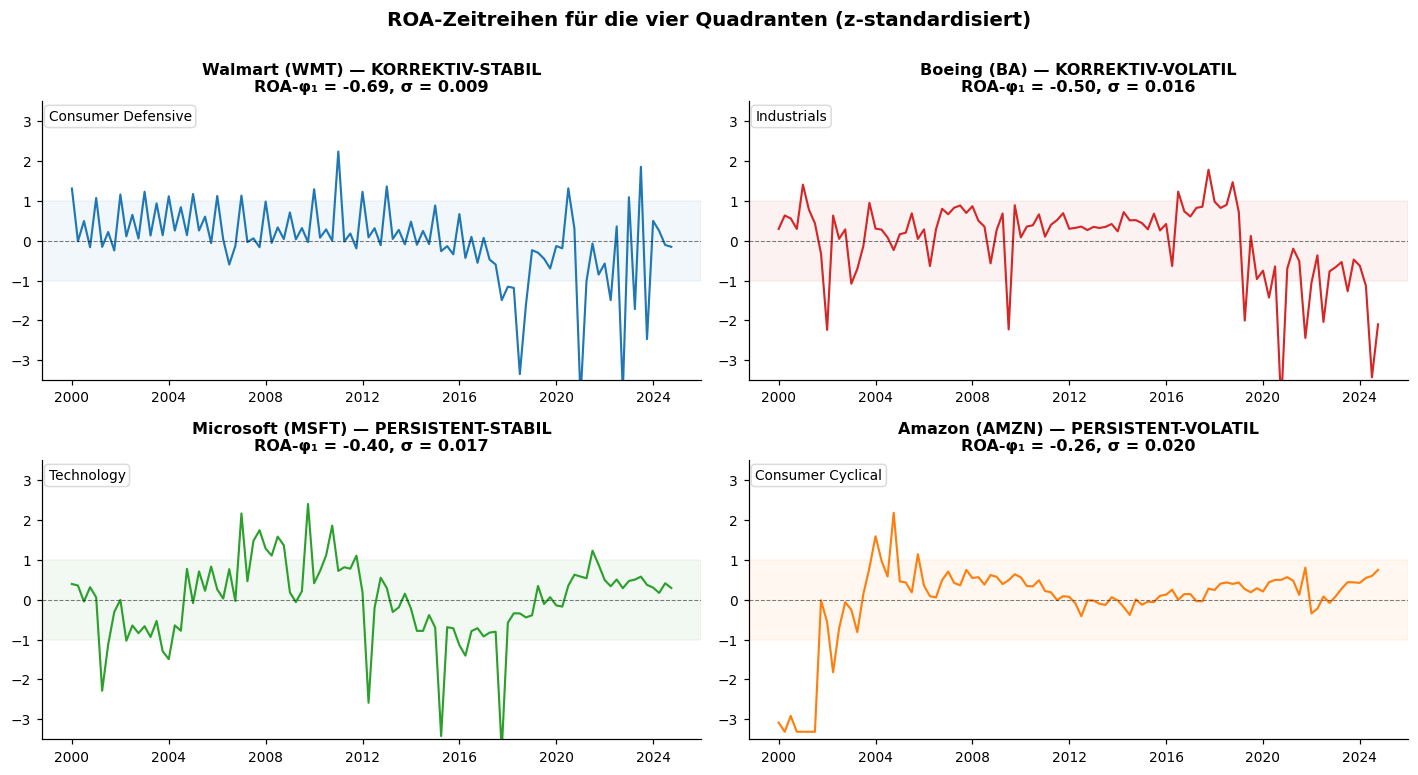

In [83]:
# Abb. 4.10 — Beispielhafte ROA-Zeitreihen, z-standardisiert
panel = ah.load_ratio_panel()
panel["quarter"] = pd.PeriodIndex(panel["quarter"], freq="Q").to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (quad, (ticker, name, sector)) in zip(axes.flatten(), EXAMPLES.items()):
    sub = panel[panel["ticker"]==ticker].sort_values("quarter").copy()
    if len(sub) == 0: continue
    z = (sub["ROA"] - sub["ROA"].mean()) / sub["ROA"].std()
    color = QUAD_COLORS[quad]
    ax.plot(sub["quarter"], z, color=color, lw=1.4)
    a = ar[(ar["ticker"]==ticker) & (ar["ratio"]=="ROA")]
    phi1 = a["phi1"].iloc[0] if len(a) else np.nan
    sig = a["sigma_diff"].iloc[0] if len(a) else np.nan
    ax.axhline(0, color="black", ls="--", lw=0.7, alpha=0.5)
    ax.axhspan(-1, 1, alpha=0.06, color=color)
    ax.set_title(f"{name} ({ticker}) — {quad}\nROA-φ₁ = {phi1:.2f}, σ = {sig:.3f}",
                 fontweight="bold", fontsize=10.5)
    ax.set_ylim(-3.5, 3.5)
    ax.text(0.01, 0.97, sector, transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="lightgray", alpha=0.8))

fig.suptitle("ROA-Zeitreihen für die vier Quadranten (z-standardisiert)",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()


---
## 4.4 Erkenntnisse aus FF1

Synthese (kein neuer Code):
1. Drei Dynamiktypen ökonomisch + statistisch trennbar
2. φ₁ und σ als unabhängige Strukturmerkmale (Spearman |ρ| < 0,25)
3. Sektorale Heterogenität moduliert die Rangordnung, hebt sie nicht auf


---
## 4.5 Robustheit


### 4.5.1 Modellvarianten

Vier AR-Spezifikationen: diff1, levels, AR(2)-diff1, Δ₄Y.

In [84]:
multi = ah.load_ar_summary_multimodel()
pivot_models = multi.pivot(index="ratio", columns="model", values="phi1_median")
pivot_models = pivot_models[["diff1","levels","ar2_diff1","diff4"]].reindex(RATIO_ORDER)
pivot_models.round(3)


model,diff1,levels,ar2_diff1,diff4
ratio,,,,
ROA,-0.431,0.361,-0.561,0.206
ROE,-0.427,0.317,-0.548,0.213
EBIT_margin,-0.431,0.360,-0.554,0.209
fcf_margin,-0.459,0.100,-0.603,0.123
current_ratio,-0.174,0.799,-0.207,0.588
debt_to_equity,-0.089,0.874,-0.097,0.663
equity_ratio,-0.040,0.929,-0.041,0.722


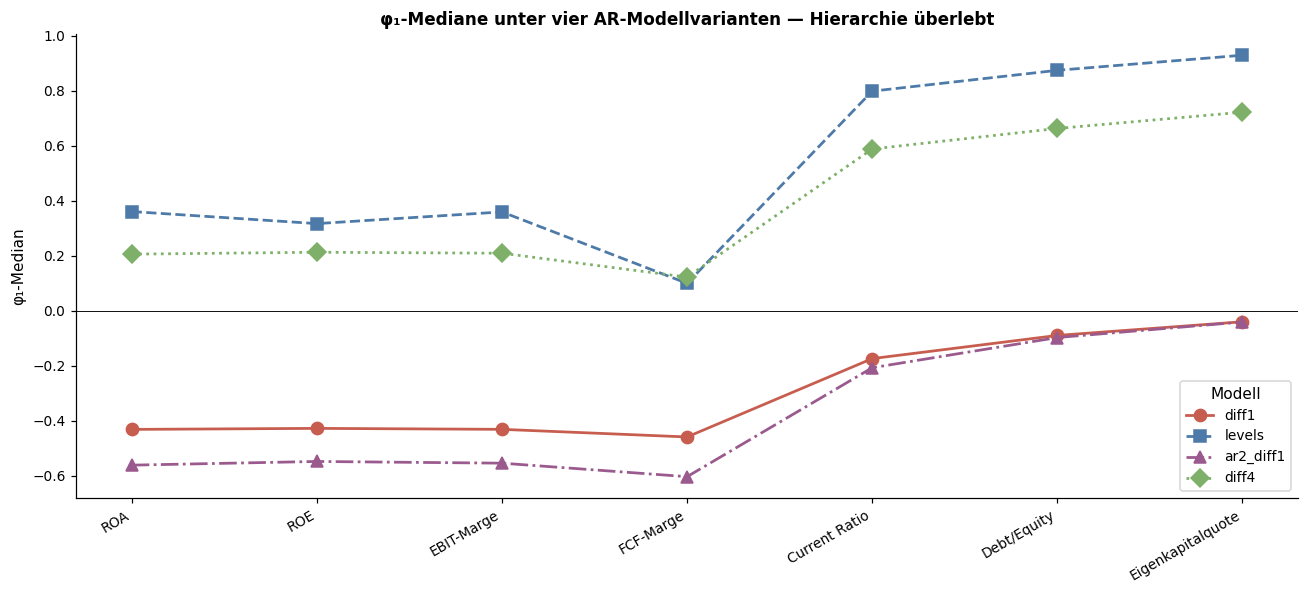

In [85]:
# Modellvergleich als Linienplot
fig, ax = plt.subplots(figsize=(12, 5.5))
markers = {"diff1": "o", "levels": "s", "ar2_diff1": "^", "diff4": "D"}
linestyles = {"diff1": "-", "levels": "--", "ar2_diff1": "-.", "diff4": ":"}
colors = {"diff1": "#C75D4F", "levels": "#4D7AA8", "ar2_diff1": "#9B5A8E", "diff4": "#7FB069"}

for model in ["diff1","levels","ar2_diff1","diff4"]:
    ax.plot(range(len(RATIO_ORDER)), pivot_models[model], 
            marker=markers[model], ls=linestyles[model], color=colors[model],
            label=model, lw=1.8, markersize=8)

ax.axhline(0, color="black", lw=0.6)
ax.set_xticks(range(len(RATIO_ORDER)))
ax.set_xticklabels([RATIO_LABEL[r] for r in RATIO_ORDER], rotation=30, ha="right")
ax.set_ylabel("φ₁-Median")
ax.set_title("φ₁-Mediane unter vier AR-Modellvarianten — Hierarchie überlebt", fontweight="bold")
ax.legend(title="Modell", loc="lower right")
plt.tight_layout()
plt.show()


### 4.5.2 Stichprobenrobustheit

Vier Vollständigkeitsschwellen: 100Q, 80Q, 60Q, 40Q.

In [86]:
samples = ah.load_sample_comparison()
samples_pivot = samples.pivot(index="ratio", columns="sample", values="phi1_median")
samples_pivot = samples_pivot.reindex(RATIO_ORDER).round(3)
samples_pivot


sample,100Q (Hauptanalyse),40Q,60Q,80Q
ratio,,,,
ROA,-0.432,-0.432,-0.433,-0.429
ROE,-0.427,-0.422,-0.425,-0.423
EBIT_margin,-0.431,-0.418,-0.426,-0.427
fcf_margin,-0.459,-0.455,-0.459,-0.460
current_ratio,-0.174,-0.174,-0.172,-0.174
debt_to_equity,-0.089,-0.104,-0.104,-0.089
equity_ratio,-0.040,-0.056,-0.053,-0.041


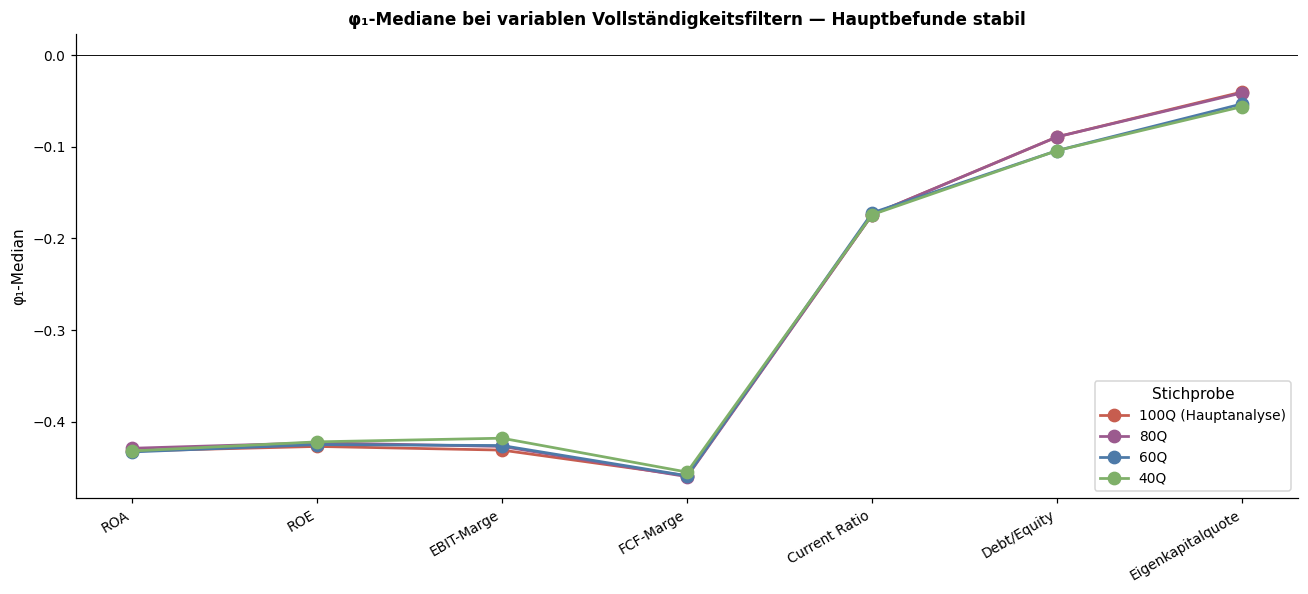

In [87]:
# Stichprobenrobustheit als Linienplot
fig, ax = plt.subplots(figsize=(12, 5.5))
sample_order = ["100Q (Hauptanalyse)", "80Q", "60Q", "40Q"]
sample_colors = {"100Q (Hauptanalyse)": "#C75D4F", "80Q": "#9B5A8E",
                  "60Q": "#4D7AA8", "40Q": "#7FB069"}

for sample in sample_order:
    if sample in samples_pivot.columns:
        ax.plot(range(len(RATIO_ORDER)), samples_pivot[sample],
                marker="o", color=sample_colors[sample], label=sample, lw=1.8, markersize=8)

ax.axhline(0, color="black", lw=0.6)
ax.set_xticks(range(len(RATIO_ORDER)))
ax.set_xticklabels([RATIO_LABEL[r] for r in RATIO_ORDER], rotation=30, ha="right")
ax.set_ylabel("φ₁-Median")
ax.set_title("φ₁-Mediane bei variablen Vollständigkeitsfiltern — Hauptbefunde stabil", fontweight="bold")
ax.legend(title="Stichprobe", loc="lower right")
plt.tight_layout()
plt.show()


### 4.5.3 Empirische Trennbarkeit der Quadrantendimensionen

In [88]:
# Tab. 4.7 — Spearman φ₁ × σ
spear = ah.load_phi1_sigma_correlation()
spear[["ratio","r_spearman","p_spearman"]].round(4)


,ratio,r_spearman,p_spearman
0,ROA,-0.0895,0.0063
1,ROE,-0.0409,0.2129
2,EBIT-M.,-0.1823,0.0000
3,FCF-M.,0.0450,0.1702
4,CR,-0.1873,0.0000
5,D/E,-0.2411,0.0000
6,EQ-R.,-0.0910,0.0055


In [89]:
# Tab. 4.8 — χ²-Test auf Quadranten-Gleichverteilung
chi2 = ah.quadrant_uniformity_chi2(ar)
chi2


,ratio,n,KS,KV,PS,PV,chi2,p_value
0,ROA,931,223,242,243,223,1.64,0.6513
1,ROE,931,224,239,242,226,1.06,0.7867
2,EBIT_margin,932,196,270,270,196,23.50,0.0000
3,fcf_margin,932,227,239,239,227,0.62,0.8923
4,current_ratio,932,200,266,266,200,18.70,0.0003
5,debt_to_equity,931,200,265,266,200,18.44,0.0004
6,equity_ratio,932,218,248,248,218,3.86,0.2767


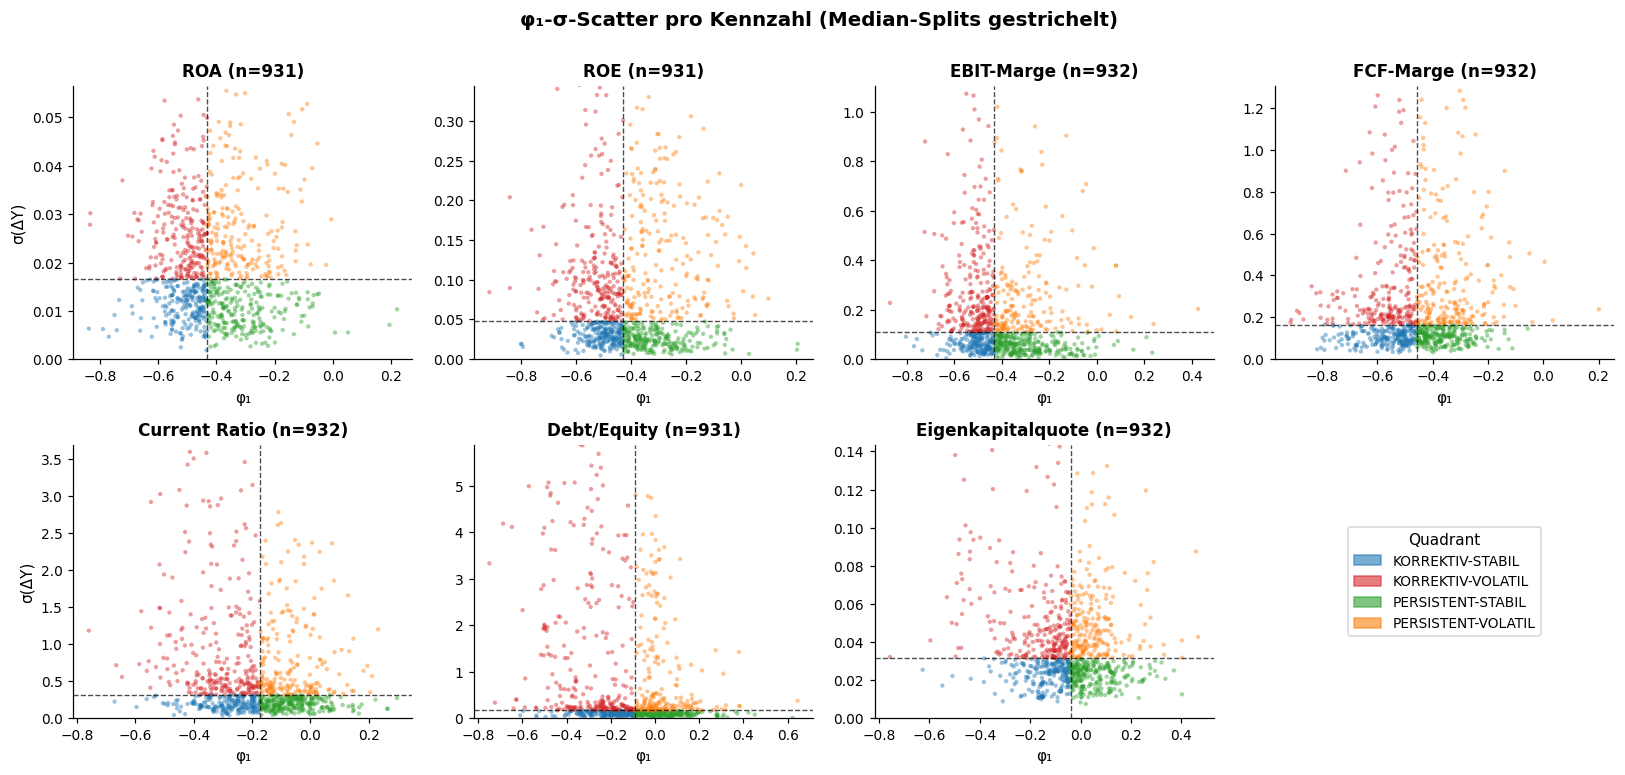

In [90]:
# Abb. 4.9 — φ₁-σ-Scatterplots
ar_q = ah.compute_quadrants(ar)
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, ratio in enumerate(RATIO_ORDER):
    ax = axes[i]
    sub = ar_q[ar_q["ratio"]==ratio]
    if len(sub) == 0: continue
    p_med = sub["phi1_median_used"].iloc[0]
    s_med = sub["sigma_median_used"].iloc[0]
    for q, col in QUAD_COLORS.items():
        qsub = sub[sub["quadrant"]==q]
        ax.scatter(qsub["phi1"], qsub["sigma_diff"], s=8, alpha=0.45, color=col, edgecolor="none")
    ax.axvline(p_med, color="black", ls="--", lw=0.9, alpha=0.7)
    ax.axhline(s_med, color="black", ls="--", lw=0.9, alpha=0.7)
    ax.set_title(f"{RATIO_LABEL[ratio]} (n={len(sub)})", fontweight="bold")
    ax.set_xlabel("φ₁")
    if i % 4 == 0: ax.set_ylabel("σ(ΔY)")
    ax.set_ylim(0, sub["sigma_diff"].quantile(0.99))

axes[7].axis("off")
quad_legend = [mpatches.Patch(color=c, alpha=0.6, label=q) for q,c in QUAD_COLORS.items()]
axes[7].legend(handles=quad_legend, loc="center", title="Quadrant")
fig.suptitle("φ₁-σ-Scatter pro Kennzahl (Median-Splits gestrichelt)",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()


### 4.5.4 Robustheit über disjunkte Zeitfenster (Periodensplit)

Die 25-jährige Hauptperiode wird in **vier disjunkte Fenster à 25 Quartale** zerlegt: W1 2000Q1–2006Q1, W2 2006Q2–2012Q2, W3 2012Q3–2018Q3, W4 2018Q4–2024Q4. Pro Fenster wird AR(1) auf 1. Differenzen erneut geschätzt – identische Spezifikation wie in der Hauptanalyse, nur auf das jeweilige Fenster zugeschnitten. Verglichen werden die Querschnittsmediane von φ₁ und σ(ΔY) pro Schicht und pro Kennzahl mit den Voll-Perioden-Medianen.

Da der balancierte 100-Quartal-Panel über alle Fenster identisch ist, variiert die Firmenzusammensetzung nicht zwischen den Fenstern – beobachtete Unterschiede sind rein temporal, nicht kompositorisch. Die Spalte `phi1_dev_max` zeigt die maximale Abweichung eines Fenster-Medians vom Voll-Periode-Median und ist das zentrale Robustheitsmaß: bleibt sie deutlich kleiner als der Schichtabstand selbst, ist die Drei-Schichten-Hierarchie zeitlich stabil.

In [91]:
# Periodensplit: AR(1) pro Firma × Kennzahl × Fenster
import warnings
from ar_model import _fit_ar

N_WINDOWS = 4
WINDOW_LEN = 100 // N_WINDOWS  # 25 Quartale
_all_q = pd.period_range(start="2000Q1", periods=100, freq="Q")
WINDOWS = [{
    "window": f"W{i+1}",
    "start":  str(_all_q[i*WINDOW_LEN]),
    "end":    str(_all_q[(i+1)*WINDOW_LEN - 1]),
} for i in range(N_WINDOWS)]

qtr = panel["quarter"].astype(str)
records = []
with warnings.catch_warnings():
    # statsmodels wirft RuntimeWarning, wenn eine 25Q-Reihe nahezu konstant
    # ist (centered_tss = 0 → R² als 0/0). R² fließt nicht in die Tabelle
    # ein, daher unterdrücken.
    warnings.simplefilter("ignore", RuntimeWarning)
    for w in WINDOWS:
        sub = panel[(qtr >= w["start"]) & (qtr <= w["end"])]
        for ticker, df_t in sub.groupby("ticker"):
            df_t = df_t.sort_values("quarter")
            for r in RATIO_ORDER:
                series = pd.Series(df_t[r].values.astype(float))
                fit = _fit_ar(series, diff_order=1, ar_lags=1)
                if fit is None:
                    continue
                records.append({"window": w["window"], "ticker": ticker, "ratio": r,
                                "phi1": fit["phi1"], "sigma_diff": fit["sigma_diff"]})

per_firm = pd.DataFrame(records)
print(f"{per_firm['ticker'].nunique()} Firmen, {len(per_firm)} Schätzungen "
      f"über {N_WINDOWS} Fenster × {len(RATIO_ORDER)} Kennzahlen")

# Tab. 4.11 — Median-Vergleich pro Kennzahl: Voll-Periode + vier Fenster
ar_full = ar[["ticker", "ratio", "phi1", "sigma_diff"]].assign(window="full")
combined = pd.concat([ar_full, per_firm], ignore_index=True)

windows_all = ["full"] + [w["window"] for w in WINDOWS]
medians = (combined.groupby(["window", "ratio"])
                   .agg(phi1=("phi1", "median"), sigma=("sigma_diff", "median"))
                   .reset_index())

phi_pivot = (medians.pivot(index="ratio", columns="window", values="phi1")
                    .reindex(columns=windows_all)
                    .add_prefix("phi1_"))
sigma_pivot = (medians.pivot(index="ratio", columns="window", values="sigma")
                      .reindex(columns=windows_all)
                      .add_prefix("sigma_"))

ratio_table = phi_pivot.join(sigma_pivot).reindex(RATIO_ORDER)

phi_w_cols   = [f"phi1_{w['window']}"  for w in WINDOWS]
sigma_w_cols = [f"sigma_{w['window']}" for w in WINDOWS]
ratio_table["phi1_dev_max"]  = ratio_table[phi_w_cols ].subtract(ratio_table["phi1_full"],  axis=0).abs().max(axis=1)
ratio_table["sigma_dev_max"] = ratio_table[sigma_w_cols].subtract(ratio_table["sigma_full"], axis=0).abs().max(axis=1)
ratio_table["Schicht"] = [RATIO_LAYER[r] for r in ratio_table.index]

ratio_table = ratio_table[
    ["Schicht", "phi1_full"] + phi_w_cols + ["phi1_dev_max",
     "sigma_full"] + sigma_w_cols + ["sigma_dev_max"]
].round(3)
ratio_table

932 Firmen, 25930 Schätzungen über 4 Fenster × 7 Kennzahlen


window,Schicht,phi1_full,phi1_W1,phi1_W2,phi1_W3,phi1_W4,phi1_dev_max,sigma_full,sigma_W1,sigma_W2,sigma_W3,sigma_W4,sigma_dev_max
ratio,,,,,,,,,,,,,
ROA,Profitabilität,-0.431,-0.385,-0.386,-0.440,-0.395,0.046,0.017,0.013,0.013,0.013,0.013,0.004
ROE,Profitabilität,-0.427,-0.385,-0.381,-0.436,-0.394,0.047,0.048,0.031,0.032,0.033,0.032,0.017
EBIT_margin,Profitabilität,-0.431,-0.396,-0.398,-0.399,-0.399,0.035,0.111,0.073,0.080,0.062,0.080,0.048
fcf_margin,Profitabilität,-0.459,-0.471,-0.436,-0.430,-0.420,0.039,0.165,0.151,0.139,0.130,0.141,0.036
current_ratio,Liquidität,-0.174,-0.147,-0.159,-0.193,-0.157,0.027,0.317,0.268,0.273,0.267,0.250,0.068
debt_to_equity,Kapitalstruktur,-0.089,-0.089,-0.090,-0.099,-0.059,0.031,0.166,0.110,0.110,0.116,0.113,0.056
equity_ratio,Kapitalstruktur,-0.040,-0.078,-0.055,-0.077,-0.037,0.039,0.031,0.028,0.028,0.025,0.022,0.009


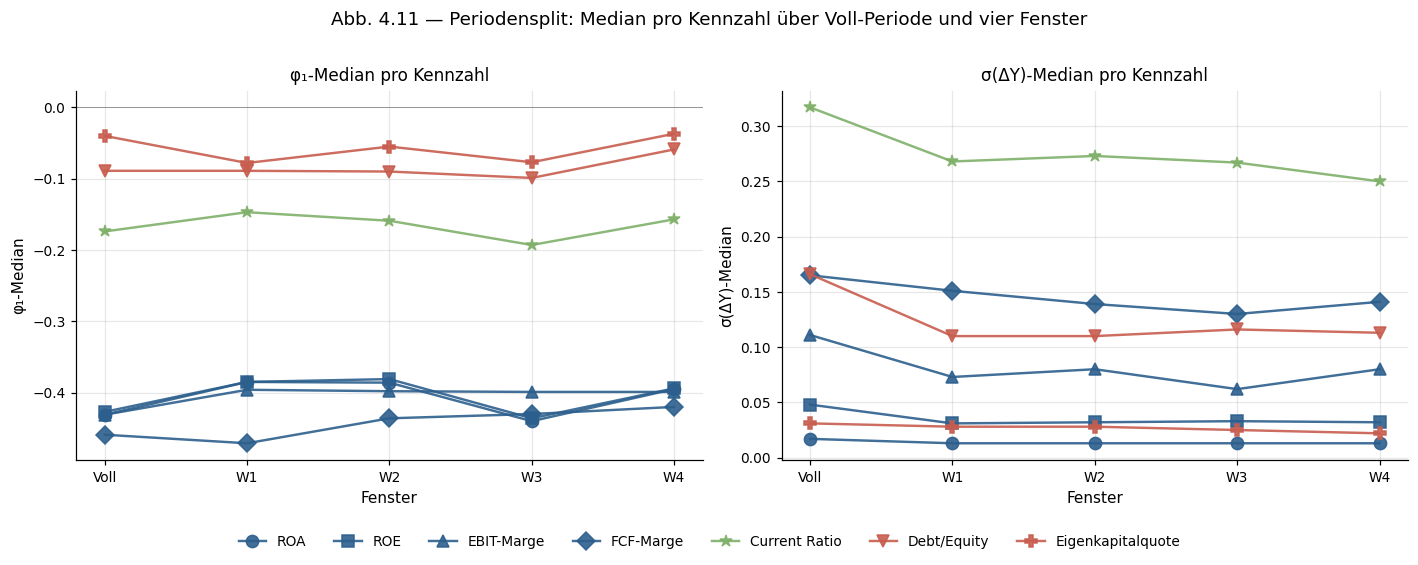

In [92]:
# Abb. 4.11 — Periodensplit: Mediane pro Kennzahl über Voll-Periode + vier Fenster
# Marker: eindeutig je Kennzahl; Farbe: Schichtzugehörigkeit (LAYER_COLORS aus Setup-Zelle)
RATIO_MARKERS = {
    "ROA": "o", "ROE": "s", "EBIT_margin": "^", "fcf_margin": "D",
    "current_ratio": "*",
    "debt_to_equity": "v", "equity_ratio": "P",
}
x_pos    = ["full", "W1", "W2", "W3", "W4"]
x_labels = ["Voll", "W1", "W2", "W3", "W4"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for r in RATIO_ORDER:
    color  = LAYER_COLORS[RATIO_LAYER[r]]
    marker = RATIO_MARKERS[r]
    phi_vals = [ratio_table.loc[r, f"phi1_{w}"]  for w in x_pos]
    sig_vals = [ratio_table.loc[r, f"sigma_{w}"] for w in x_pos]
    axes[0].plot(x_labels, phi_vals, marker=marker, color=color,
                 label=RATIO_LABEL[r], linewidth=1.6, markersize=8, alpha=0.9)
    axes[1].plot(x_labels, sig_vals, marker=marker, color=color,
                 label=RATIO_LABEL[r], linewidth=1.6, markersize=8, alpha=0.9)

axes[0].axhline(0, color="grey", linewidth=0.5)
axes[0].set_title("φ₁-Median pro Kennzahl")
axes[0].set_xlabel("Fenster")
axes[0].set_ylabel("φ₁-Median")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("σ(ΔY)-Median pro Kennzahl")
axes[1].set_xlabel("Fenster")
axes[1].set_ylabel("σ(ΔY)-Median")
axes[1].grid(True, alpha=0.3)

# Eine gemeinsame Legende unter den beiden Plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=7, frameon=False,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Abb. 4.11 — Periodensplit: Median pro Kennzahl über Voll-Periode und vier Fenster",
             fontsize=12)

# Layout: Platz für die untere Legende lassen
plt.tight_layout(rect=[0, 0.05, 1, 0.97])


### 4.5.5 Asymmetrie der Mean-Reversion

TAR(1)-Modell mit Vorzeichen-Split der Lag-Variable:

$$\Delta Y_t = c + \varphi_1^+ \cdot \max(0, \Delta Y_{t-1}) + \varphi_1^- \cdot \min(0, \Delta Y_{t-1}) + \varepsilon_t$$

φ⁺ misst Mean-Reversion nach positivem Vorquartalsschock, φ⁻ nach negativem. Asymmetrie = φ⁺ − φ⁻. Wilcoxon-Test der Differenz pro Kennzahl, Bonferroni-Korrektur über 7 Tests (α = 0,05/7 ≈ 0,007).


In [93]:
# Tab. 4.12 — Asymmetrie-Summary
asym_summary = pd.read_csv(ROOT / "output/ar/asymmetry_summary.csv")
asym_summary.set_index("ratio").reindex(RATIO_ORDER).reset_index()


,ratio,n,phi_plus_median,phi_minus_median,asymmetry_median,wilcoxon_p,sig_05,sig_bonferroni
0,ROA,932,-0.2555,-0.5621,0.3224,0.0,True,True
1,ROE,932,-0.2371,-0.5585,0.3321,0.0,True,True
2,EBIT_margin,932,-0.1105,-0.7006,0.5936,0.0,True,True
3,fcf_margin,932,-0.3340,-0.5806,0.2407,0.0,True,True
4,current_ratio,932,-0.2641,-0.0540,-0.2102,0.0,True,True
5,debt_to_equity,931,-0.1489,0.0395,-0.2515,0.0,True,True
6,equity_ratio,932,0.0150,-0.0463,0.0745,0.0,True,True


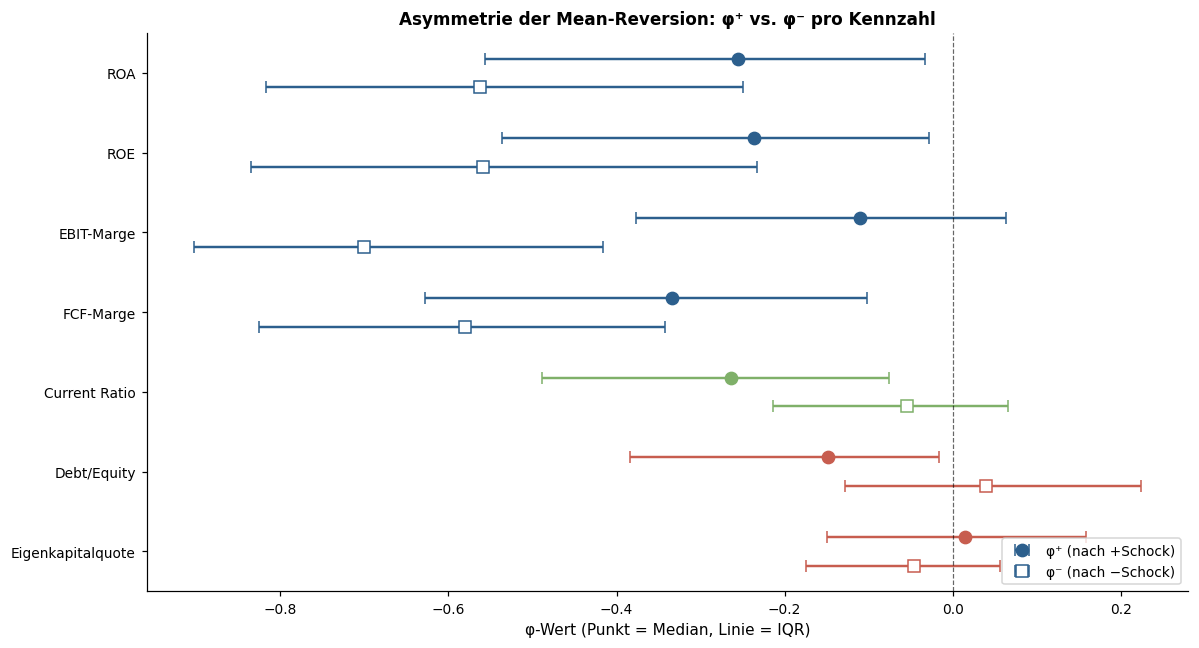

Bonferroni-resistente Asymmetrie: 7/7 Kennzahlen
  → Asymmetrie-Befund ist statistisch hochrobust gegen multiples Testen.


In [94]:
# Abb. 4.12 — Forest-Plot phi_plus vs. phi_minus pro Kennzahl
asym_full = pd.read_csv(ROOT / "output/ar/asymmetry_test.csv")

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(RATIO_ORDER))[::-1]  # oben Profitabilität, unten Kapitalstruktur

for i, ratio in enumerate(RATIO_ORDER):
    sub = asym_full[asym_full["ratio"]==ratio].dropna(subset=["phi_plus","phi_minus"])
    pp_med = sub["phi_plus"].median()
    pp_iqr = (sub["phi_plus"].quantile(0.25), sub["phi_plus"].quantile(0.75))
    pm_med = sub["phi_minus"].median()
    pm_iqr = (sub["phi_minus"].quantile(0.25), sub["phi_minus"].quantile(0.75))
    color = LAYER_COLORS[RATIO_LAYER[ratio]]
    yp = y_pos[i]
    # Pluspunkt etwas oben, Minuspunkt etwas unten
    ax.errorbar([pp_med], [yp+0.18], xerr=[[pp_med-pp_iqr[0]], [pp_iqr[1]-pp_med]],
                fmt="o", color=color, capsize=4, lw=1.6, markersize=8, label="φ⁺ (nach +Schock)" if i==0 else None)
    ax.errorbar([pm_med], [yp-0.18], xerr=[[pm_med-pm_iqr[0]], [pm_iqr[1]-pm_med]],
                fmt="s", color=color, mfc="white", capsize=4, lw=1.6, markersize=8,
                label="φ⁻ (nach −Schock)" if i==0 else None)

ax.set_yticks(y_pos)
ax.set_yticklabels([RATIO_LABEL[r] for r in RATIO_ORDER])
ax.axvline(0, color="black", ls="--", lw=0.8, alpha=0.6)
ax.set_xlabel("φ-Wert (Punkt = Median, Linie = IQR)")
ax.set_title("Asymmetrie der Mean-Reversion: φ⁺ vs. φ⁻ pro Kennzahl",
             fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Bonferroni-Befund
n_bonf = asym_summary["sig_bonferroni"].sum()
print(f"Bonferroni-resistente Asymmetrie: {n_bonf}/7 Kennzahlen")
print(f"  → Asymmetrie-Befund ist statistisch hochrobust gegen multiples Testen.")
